# Data Loading and Statistics

In [266]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")
np.random.seed(42)
train_path = "train.csv"
test_path = "test.csv"
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
numeric_cols = ["budget", "popularity", "runtime", "vote_average", "vote_count"]
text_col = "overview"
genre_col = "genres"
print("\nMissing values (train):")
print(train_df.isna().sum())
print("Dataset Summary:")
print(train_df.describe())
print("Dataset Info:")
print(train_df.info())

Train shape: (577853, 20)
Test shape: (144464, 20)

Missing values (train):
id                           0
title                        2
genres                  168380
original_language            0
overview                 94730
popularity                   0
production_companies    308070
release_date             41273
budget                       0
revenue                      0
runtime                  27575
status                       0
tagline                 490815
vote_average                 0
vote_count                   0
credits                 179795
keywords                409361
poster_path             147607
backdrop_path           399180
recommendations         548998
dtype: int64
Dataset Summary:
                  id     popularity        budget       revenue       runtime  \
count  577853.000000  577853.000000  5.778530e+05  5.778530e+05  5.502780e+05   
mean   526862.257868       1.931047  4.092235e+05  1.004666e+06  1.445484e+02   
std    253033.721990      24.57

# Preprocessing

In [267]:
POSITIVE_WORDS = {"good", "great", "amazing", "love", "best", "wonderful", "positive", "joy", "hero"}
NEGATIVE_WORDS = {"bad", "poor", "awful", "hate", "worst", "terrible", "sad", "villain", "dark"}
def clean_overview(text):
    if pd.isna(text):
        return ""
    return str(text).strip()
def extract_text_features(text):
    tokens = text.split()
    n_tokens = len(tokens)
    avg_len = np.mean([len(t) for t in tokens]) if tokens else 0.0
    pos_hits = sum(1 for t in tokens if t.lower() in POSITIVE_WORDS)
    neg_hits = sum(1 for t in tokens if t.lower() in NEGATIVE_WORDS)
    sentiment = (pos_hits - neg_hits) / n_tokens if n_tokens else 0.0
    return n_tokens, avg_len, sentiment
def clean_numeric(df):
    df = df.copy()
    # Remove rows where budget or revenue <= 0
    df = df[(df["budget"] > 0) & (df["revenue"] > 0)].reset_index(drop=True)
    # Fill missing values in other numeric columns with median
    for col in numeric_cols:
        if col not in ["budget", "revenue"]:
            df[col] = pd.to_numeric(df[col], errors="coerce")
            df[col] = df[col].fillna(df[col].median())
    return df
def extract_main_genre(raw_value):
    if pd.isna(raw_value):
        return "Unknown"
    first = str(raw_value).split("-")[0].strip()
    return first or "Unknown"
print(f"Train before cleaning: {len(train_df)} rows")
print(f"Test before cleaning: {len(test_df)} rows")
# Remove duplicates
train_df = train_df.drop_duplicates(subset="id", keep="first").reset_index(drop=True)
if "id" in test_df.columns:
    test_df = test_df.drop_duplicates(subset="id", keep="first").reset_index(drop=True)
print(f"After removing duplicates - Train: {len(train_df)} rows, Test: {len(test_df)} rows")
# Remove rows where overview is NaN 
overview_nan_train = train_df[text_col].isna().sum()
overview_nan_test = test_df[text_col].isna().sum()
print(f"\nRemoving rows with NaN overview:")
print(f"  Train: {overview_nan_train} rows with NaN overview")
print(f"  Test: {overview_nan_test} rows with NaN overview")
train_df = train_df[train_df[text_col].notna()].reset_index(drop=True)
test_df = test_df[test_df[text_col].notna()].reset_index(drop=True)
print(f"After removing NaN overview - Train: {len(train_df)} rows, Test: {len(test_df)} rows")
# Clean text
train_df[text_col] = train_df[text_col].apply(clean_overview)
test_df[text_col] = test_df[text_col].apply(clean_overview)
# Clean numeric
train_df = clean_numeric(train_df)
test_df = clean_numeric(test_df)
print(f"Train after cleaning numeric: {len(train_df)} rows")
print(f"Test after cleaning numeric: {len(test_df)} rows")
# Extract main genre
train_df["main_genre"] = train_df[genre_col].apply(extract_main_genre)
test_df["main_genre"] = test_df[genre_col].apply(extract_main_genre)
# Remove rows with "Unknown" genre
unknown_train_count = (train_df["main_genre"] == "Unknown").sum()
unknown_test_count = (test_df["main_genre"] == "Unknown").sum()
print(f"\nRemoving 'Unknown' genre rows:")
print(f"  Train: {unknown_train_count} rows with 'Unknown' genre")
print(f"  Test: {unknown_test_count} rows with 'Unknown' genre")
train_df = train_df[train_df["main_genre"] != "Unknown"].reset_index(drop=True)
test_df = test_df[test_df["main_genre"] != "Unknown"].reset_index(drop=True)
print(f"Train after removing 'Unknown': {len(train_df)} rows")
print(f"Test after removing 'Unknown': {len(test_df)} rows")
# Extract text features
for df_name, df in {"train": train_df, "test": test_df}.items():
    df[["overview_word_count", "overview_avg_len", "overview_sentiment"]] = df[text_col].apply(
        lambda txt: pd.Series(extract_text_features(txt)))
print("\nProcessed train sample:\n")
train_df.head()

Train before cleaning: 577853 rows
Test before cleaning: 144464 rows
After removing duplicates - Train: 538487 rows, Test: 141933 rows

Removing rows with NaN overview:
  Train: 89864 rows with NaN overview
  Test: 23222 rows with NaN overview
After removing NaN overview - Train: 448623 rows, Test: 118711 rows
Train after cleaning numeric: 8466 rows
Test after cleaning numeric: 2213 rows

Removing 'Unknown' genre rows:
  Train: 303 rows with 'Unknown' genre
  Test: 87 rows with 'Unknown' genre
Train after removing 'Unknown': 8163 rows
Test after removing 'Unknown': 2126 rows

Processed train sample:



,id,title,genres,original_language,overview,popularity,production_companies,release_date,budget,revenue,...,vote_count,credits,keywords,poster_path,backdrop_path,recommendations,main_genre,overview_word_count,overview_avg_len,overview_sentiment
0,88451,"Yes, Giorgio",Music-Drama-Comedy-Romance,en,A famous opera singer Giorgio Fini loses his v...,1.517,Metro-Goldwyn-Mayer,1982-09-24,19000000.0,2279543.0,...,7.0,Luciano Pavarotti-Kathryn Harrold-Eddie Albert...,opera-musical,/8tlLS2hbj98C3CnY2BnmE9y4opx.jpg,/9fRP5773zsmRB9zXUN7mb0Vybgd.jpg,NaN,Music,28.0,4.571429,0.035714
1,157849,A Most Wanted Man,Thriller,en,A Chechen Muslim illegally immigrates to Hambu...,13.389,Senator Film-Potboiler Productions-Lionsgate-F...,2014-07-25,15000000.0,31554855.0,...,1176.0,Philip Seymour Hoffman-Willem Dafoe-Robin Wrig...,spy-muslim-based on novel or book-intelligence...,/6B76Z5Ct758RfKFoFg37skVRiMp.jpg,/1BdN7Yej8wRnvxcXmKUyFhEMP8R.jpg,169917-157832-192149-254904-87496-241239-12103...,Thriller,25.0,5.520000,0.000000
2,8738,The Final Countdown,War-Action-Science Fiction,en,During routine manoeuvres near Hawaii in 1980 ...,15.605,Bryna Productions,1980-01-31,12000000.0,16647800.0,...,488.0,Kirk Douglas-Martin Sheen-Katharine Ross-James...,world war ii-pearl harbor-airplane-time travel...,/5030ETN6IBCjRMmZVCTGhujO5Q6.jpg,/jATKBxUklNRhqiyLM4FYXr6D1Jn.jpg,11372-11422-10606-331446-5902-11639-9075-698-9...,War,34.0,5.264706,0.000000
3,435029,Sarvann,Comedy-Action-Adventure-Family,pa,It is an action drama film about an NRI boy Mi...,1.169,Purple Pebble Pictures,2017-01-13,700000.0,2100000.0,...,2.0,Amrinder Gill-Simi Chahal-Ranjit Bawa-Amberdee...,NaN,/9eupRSlbFeLOR1FmrLbQCQ1sDWs.jpg,NaN,NaN,Comedy,20.0,3.800000,0.000000
4,168705,BloodRayne,Action-Fantasy-Horror,en,In 18th-century Romania after spending much of...,13.324,Herold Productions-Pitchblack Pictures Inc.-Bo...,2005-10-22,25000000.0,3650275.0,...,433.0,Kristanna Loken-Ben Kingsley-Michelle Rodrigue...,fight-secret society-vampire-village-vampire h...,/1xmYrKxBdCgcHgF8m9YUnwthLxF.jpg,/noWdMYkuYHnti9wrDg5ufJFl9Ks.jpg,12142-11059-17456-12685-7916-2312-252360-9053-...,Action,62.0,4.725806,0.000000


# Normalization

In [268]:
feature_cols = numeric_cols + ["overview_word_count", "overview_avg_len", "overview_sentiment"]
def normalize_numeric(df, cols, stats=None):
    data = df[cols].to_numpy(dtype=np.float32)
    if stats is None:
        mean = data.mean(axis=0)
        std = data.std(axis=0)
        std[std == 0] = 1.0
        stats = {"mean": mean, "std": std}
    normalized = (data - stats["mean"]) / stats["std"]
    return normalized, stats
train_numeric, norm_stats = normalize_numeric(train_df, feature_cols)
test_numeric, _ = normalize_numeric(test_df, feature_cols, stats=norm_stats)
print("Normalized numeric feature shape:", train_numeric.shape, test_numeric.shape)
y_revenue = train_df["revenue"].to_numpy(dtype=np.float32)
unique_genres = sorted(train_df["main_genre"].unique())
genre_to_idx = {genre: idx for idx, genre in enumerate(unique_genres)}
y_genre = train_df["main_genre"].map(genre_to_idx).to_numpy(dtype=np.int32)
y_genre_test = test_df["main_genre"].map(genre_to_idx).to_numpy(dtype=np.int32)
y_revenue_test = test_df["revenue"].to_numpy(dtype=np.float32)
print("Revenue target shape:", y_revenue.shape)
print("Genre classes:", len(genre_to_idx))
print("Test set labels shape:", y_genre_test.shape)

Normalized numeric feature shape: (8163, 8) (2126, 8)
Revenue target shape: (8163,)
Genre classes: 19
Test set labels shape: (2126,)


# TF-IDF

In [269]:
def tokenize(text):
    if pd.isna(text):
        return []
    tokens = []
    for raw in str(text).lower().split():
        token = raw.strip(".,!?()[]{}:;\"'`“”’–-_")
        if token:
            tokens.append(token)
    return tokens
def build_vocabulary(texts, min_df=20, max_features=2000):
    df_counts = {}
    total_docs = len(texts)
    for text in texts:
        seen = set()
        for token in tokenize(text):
            if token not in seen:
                df_counts[token] = df_counts.get(token, 0) + 1
                seen.add(token)
    filtered = [(tok, cnt) for tok, cnt in df_counts.items() if cnt >= min_df]
    filtered.sort(key=lambda x: (-x[1], x[0]))
    vocab = [tok for tok, _ in filtered[:max_features]]
    idf = {
        tok: np.log((1 + total_docs) / (1 + df_counts[tok])) + 1.0
        for tok in vocab
    }
    index = {tok: i for i, tok in enumerate(vocab)}
    return vocab, idf, index
def compute_tfidf_matrix(texts, vocab_index, idf_values):
    n_docs = len(texts)
    n_terms = len(vocab_index)
    matrix = np.zeros((n_docs, n_terms), dtype=np.float32)
    for doc_idx, text in enumerate(texts):
        tokens = tokenize(text)
        if not tokens:
            continue
        tf_counts = {}
        for token in tokens:
            if token in vocab_index:
                tf_counts[token] = tf_counts.get(token, 0) + 1
        if not tf_counts:
            continue
        doc_total = sum(tf_counts.values())
        for token, count in tf_counts.items():
            col = vocab_index[token]
            tf = count / doc_total
            matrix[doc_idx, col] = tf * idf_values[token]
    return matrix
all_overviews = pd.concat([train_df[text_col], test_df[text_col]], ignore_index=True)
vocab, idf_scores, vocab_index = build_vocabulary(all_overviews, min_df=20, max_features=1000)
print(f"Vocabulary size: {len(vocab)}")
train_tfidf = compute_tfidf_matrix(train_df[text_col], vocab_index, idf_scores)
test_tfidf = compute_tfidf_matrix(test_df[text_col], vocab_index, idf_scores)
print("TF-IDF shapes:", train_tfidf.shape, test_tfidf.shape)

Vocabulary size: 1000
TF-IDF shapes: (8163, 1000) (2126, 1000)


In [270]:
import matplotlib.pyplot as plt
import seaborn as sns
X_train = np.hstack([train_numeric, train_tfidf])
X_test = np.hstack([test_numeric, test_tfidf])
print(f"Combined feature shape - Train: {X_train.shape}, Test: {X_test.shape}")

Combined feature shape - Train: (8163, 1008), Test: (2126, 1008)


# Classification Models - Genre Classification

## Classification Metrics

In [271]:
def compute_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)
def compute_precision_recall_f1(y_true, y_pred, n_classes):
    precision = np.zeros(n_classes)
    recall = np.zeros(n_classes)
    f1 = np.zeros(n_classes)
    for c in range(n_classes):
        tp = np.sum((y_true == c) & (y_pred == c))
        fp = np.sum((y_true != c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))
        precision[c] = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall[c] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1[c] = 2 * precision[c] * recall[c] / (precision[c] + recall[c]) if (precision[c] + recall[c]) > 0 else 0.0
    return precision, recall, f1
def compute_confusion_matrix(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for true, pred in zip(y_true, y_pred):
        cm[true, pred] += 1
    return cm
def kfold_cv_classification(X, y, model_class, k=5, **model_params):
    n_samples = len(X)
    fold_size = n_samples // k
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    all_y_true = []
    all_y_pred = []
    for i in range(k):
        start = i * fold_size
        end = (i + 1) * fold_size if i < k - 1 else n_samples
        val_indices = indices[start:end]
        train_indices = np.concatenate([indices[:start], indices[end:]])
        X_train_fold, X_val_fold = X[train_indices], X[val_indices]
        y_train_fold, y_val_fold = y[train_indices], y[val_indices]
        model = model_class(**model_params)
        model.fit(X_train_fold, y_train_fold)
        y_pred = model.predict(X_val_fold)
        all_y_true.extend(y_val_fold)
        all_y_pred.extend(y_pred)
    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)
    n_classes = len(np.unique(y))
    accuracy = compute_accuracy(all_y_true, all_y_pred)
    precision, recall, f1 = compute_precision_recall_f1(all_y_true, all_y_pred, n_classes)
    cm = compute_confusion_matrix(all_y_true, all_y_pred, n_classes)
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm,
        "y_true": all_y_true,
        "y_pred": all_y_pred
    }
def print_classification_results(model_name, results, class_names):
    print(f"{model_name}")
    print(f"\nAccuracy: {results['accuracy']:.4f}")
    print(f"\nMacro-average Precision: {np.mean(results['precision']):.4f}")
    print(f"Macro-average Recall: {np.mean(results['recall']):.4f}")
    print(f"Macro-average F1-score: {np.mean(results['f1']):.4f}")
    print(f"\nPer-class metrics:")
    for i, name in enumerate(class_names):
        print(f"  {name:15s} - P: {results['precision'][i]:.4f}, "
              f"R: {results['recall'][i]:.4f}, F1: {results['f1'][i]:.4f}")
    cm = results['confusion_matrix']
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'}, linewidths=0.5)
    plt.title(f'Confusion Matrix (Raw Counts) - {model_name}', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Predicted Genre', fontsize=12, fontweight='bold')
    plt.ylabel('True Genre', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

## Logistic Regression


Training Logistic Regression Classifier...
1. LOGISTIC REGRESSION

Accuracy: 0.2887

Macro-average Precision: 0.0508
Macro-average Recall: 0.0712
Macro-average F1-score: 0.0525

Per-class metrics:
  Action          - P: 0.2727, R: 0.2512, F1: 0.2615
  Adventure       - P: 0.0000, R: 0.0000, F1: 0.0000
  Animation       - P: 0.0000, R: 0.0000, F1: 0.0000
  Comedy          - P: 0.2632, R: 0.3432, F1: 0.2979
  Crime           - P: 0.0000, R: 0.0000, F1: 0.0000
  Documentary     - P: 0.0000, R: 0.0000, F1: 0.0000
  Drama           - P: 0.3051, R: 0.7557, F1: 0.4347
  Family          - P: 0.0000, R: 0.0000, F1: 0.0000
  Fantasy         - P: 0.0000, R: 0.0000, F1: 0.0000
  History         - P: 0.0000, R: 0.0000, F1: 0.0000
  Horror          - P: 0.1250, R: 0.0018, F1: 0.0036
  Music           - P: 0.0000, R: 0.0000, F1: 0.0000
  Mystery         - P: 0.0000, R: 0.0000, F1: 0.0000
  Romance         - P: 0.0000, R: 0.0000, F1: 0.0000
  Science Fiction - P: 0.0000, R: 0.0000, F1: 0.0000
  TV Mo

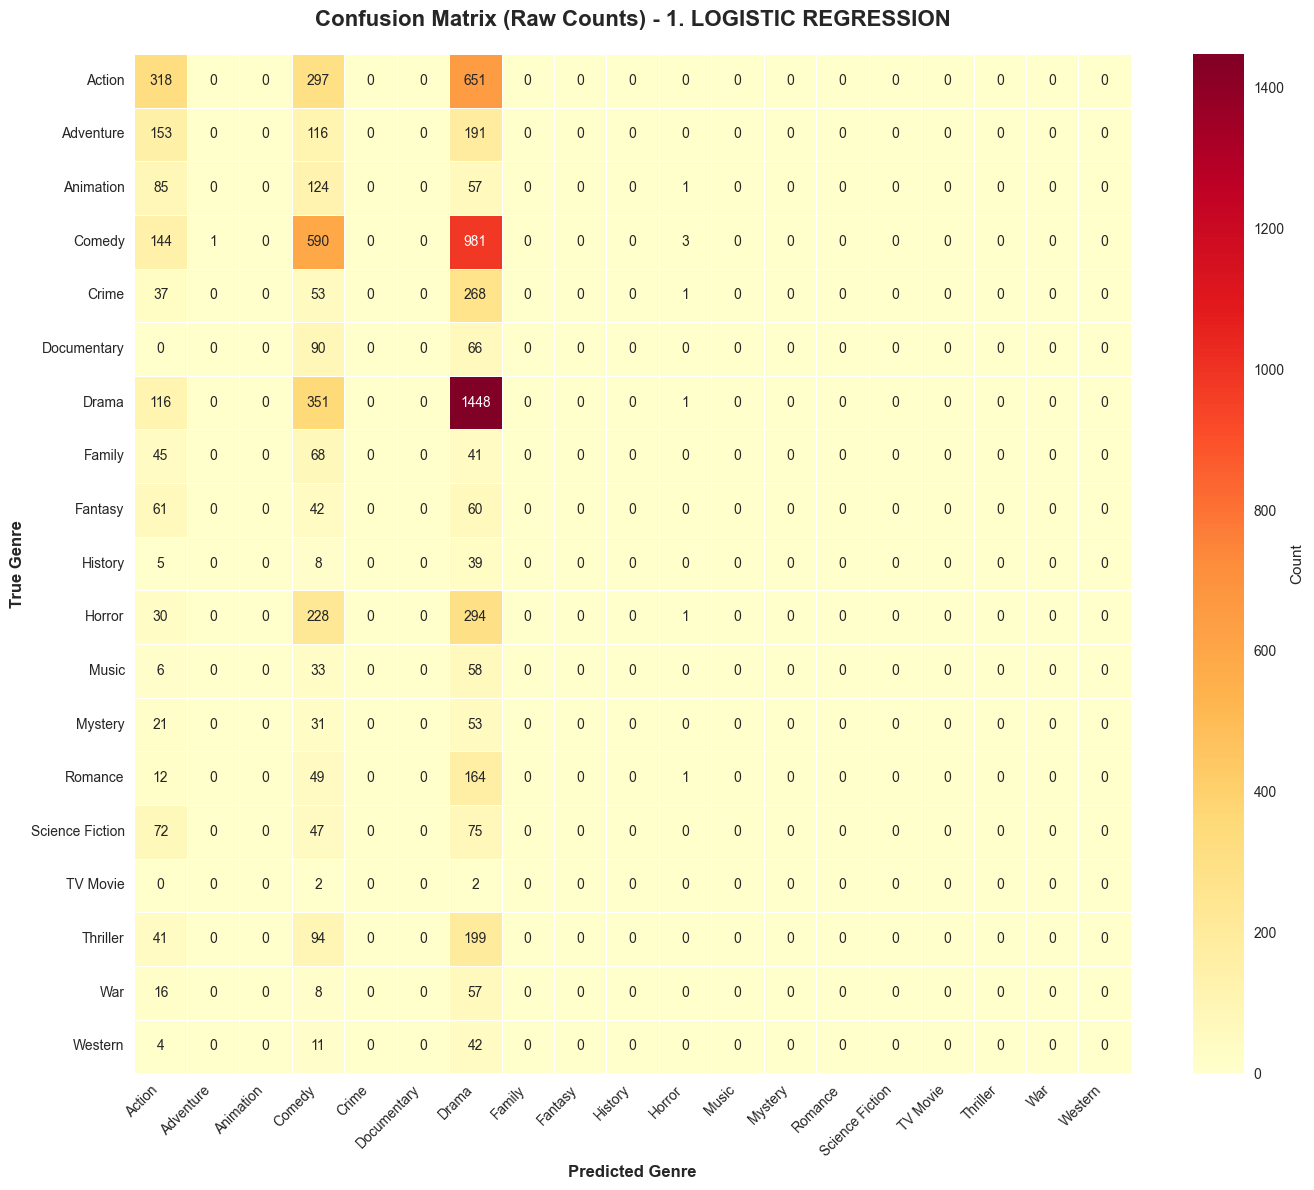

Evaluating on Test Set...
1. LOGISTIC REGRESSION (Test Set)

Accuracy: 0.2752

Macro-average Precision: 0.0412
Macro-average Recall: 0.0667
Macro-average F1-score: 0.0489

Per-class metrics:
  Action          - P: 0.2545, R: 0.2303, F1: 0.2418
  Adventure       - P: 0.0000, R: 0.0000, F1: 0.0000
  Animation       - P: 0.0000, R: 0.0000, F1: 0.0000
  Comedy          - P: 0.2254, R: 0.3077, F1: 0.2602
  Crime           - P: 0.0000, R: 0.0000, F1: 0.0000
  Documentary     - P: 0.0000, R: 0.0000, F1: 0.0000
  Drama           - P: 0.3021, R: 0.7302, F1: 0.4274
  Family          - P: 0.0000, R: 0.0000, F1: 0.0000
  Fantasy         - P: 0.0000, R: 0.0000, F1: 0.0000
  History         - P: 0.0000, R: 0.0000, F1: 0.0000
  Horror          - P: 0.0000, R: 0.0000, F1: 0.0000
  Music           - P: 0.0000, R: 0.0000, F1: 0.0000
  Mystery         - P: 0.0000, R: 0.0000, F1: 0.0000
  Romance         - P: 0.0000, R: 0.0000, F1: 0.0000
  Science Fiction - P: 0.0000, R: 0.0000, F1: 0.0000
  TV Movie    

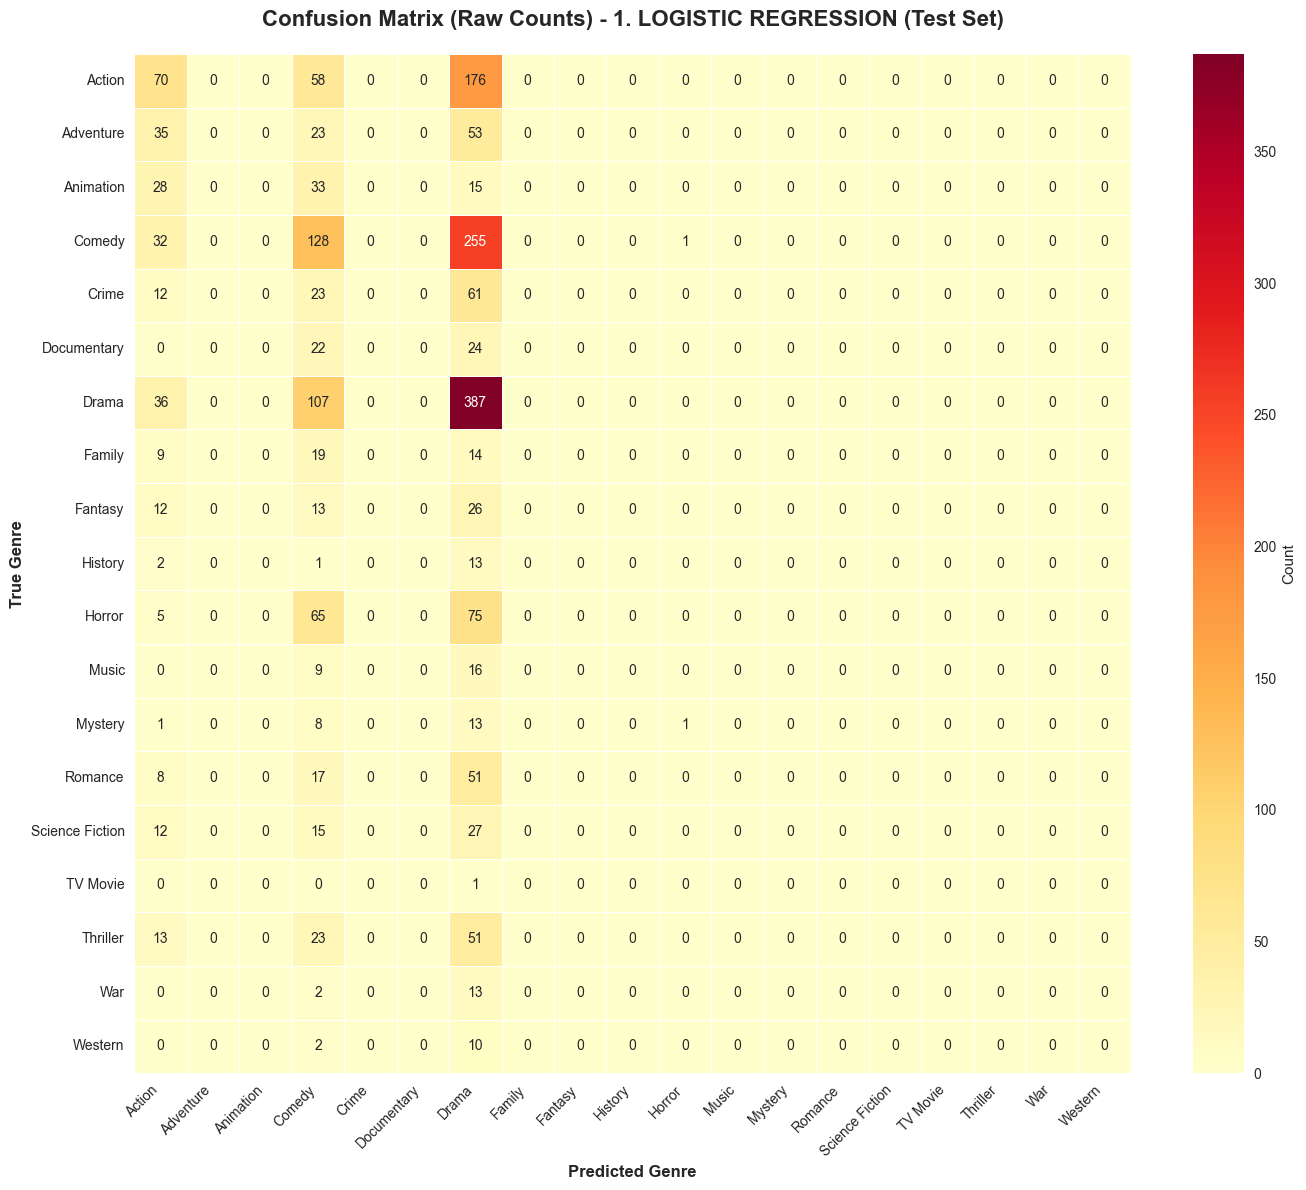

In [272]:
class LogisticRegression:
    def __init__(self, learning_rate=0.1, max_iter=200, tol=1e-4):
        self.lr = learning_rate
        self.max_iter = max_iter
        self.tol = tol
        self.weights = None
        self.bias = None
        self.n_classes = None
    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.n_classes = len(np.unique(y))
        self.weights = np.random.randn(n_features, self.n_classes) * 0.01
        self.bias = np.zeros(self.n_classes)
        for i in range(self.max_iter):
            z = X @ self.weights + self.bias
            probs = self.softmax(z)
            y_onehot = np.eye(self.n_classes)[y]
            error = probs - y_onehot
            grad_w = (X.T @ error) / n_samples
            grad_b = np.mean(error, axis=0)
            prev_weights = self.weights.copy()
            self.weights -= self.lr * grad_w
            self.bias -= self.lr * grad_b
            weight_change = np.linalg.norm(self.weights - prev_weights)
            if weight_change < self.tol:
                break
                print(f"Converged in {i+1} iterations")
    def predict(self, X):
        z = X @ self.weights + self.bias
        probs = self.softmax(z)
        return np.argmax(probs, axis=1)
print("\nTraining Logistic Regression Classifier...")
lr_results = kfold_cv_classification(X_train, y_genre, LogisticRegression, k=5, learning_rate=0.01, max_iter=1000)
print_classification_results("1. LOGISTIC REGRESSION", lr_results, unique_genres)
print("Evaluating on Test Set...")
model_lr = LogisticRegression(learning_rate=0.01, max_iter=1000)
model_lr.fit(X_train, y_genre)
y_pred_test = model_lr.predict(X_test)
n_classes = len(unique_genres)
lr_test_results = {
    "accuracy": compute_accuracy(y_genre_test, y_pred_test),
    "precision": compute_precision_recall_f1(y_genre_test, y_pred_test, n_classes)[0],
    "recall": compute_precision_recall_f1(y_genre_test, y_pred_test, n_classes)[1],
    "f1": compute_precision_recall_f1(y_genre_test, y_pred_test, n_classes)[2],
    "confusion_matrix": compute_confusion_matrix(y_genre_test, y_pred_test, n_classes),
    "y_true": y_genre_test,
    "y_pred": y_pred_test
}
print_classification_results("1. LOGISTIC REGRESSION (Test Set)", lr_test_results, unique_genres)

## K-Nearest Neighbors (KNN)



Training KNN Classifier (k=5)...
2. K-NEAREST NEIGHBORS (KNN)

Accuracy: 0.2630

Macro-average Precision: 0.1015
Macro-average Recall: 0.0930
Macro-average F1-score: 0.0908

Per-class metrics:
  Action          - P: 0.2267, R: 0.3657, F1: 0.2799
  Adventure       - P: 0.1078, R: 0.1022, F1: 0.1049
  Animation       - P: 0.1396, R: 0.1161, F1: 0.1268
  Comedy          - P: 0.2739, R: 0.3438, F1: 0.3049
  Crime           - P: 0.1123, R: 0.0585, F1: 0.0769
  Documentary     - P: 0.2209, R: 0.1218, F1: 0.1570
  Drama           - P: 0.3665, R: 0.4609, F1: 0.4083
  Family          - P: 0.0625, R: 0.0130, F1: 0.0215
  Fantasy         - P: 0.0714, R: 0.0123, F1: 0.0209
  History         - P: 0.0000, R: 0.0000, F1: 0.0000
  Horror          - P: 0.2305, R: 0.1447, F1: 0.1778
  Music           - P: 0.0000, R: 0.0000, F1: 0.0000
  Mystery         - P: 0.0000, R: 0.0000, F1: 0.0000
  Romance         - P: 0.0455, R: 0.0088, F1: 0.0148
  Science Fiction - P: 0.0222, R: 0.0052, F1: 0.0084
  TV Movie 

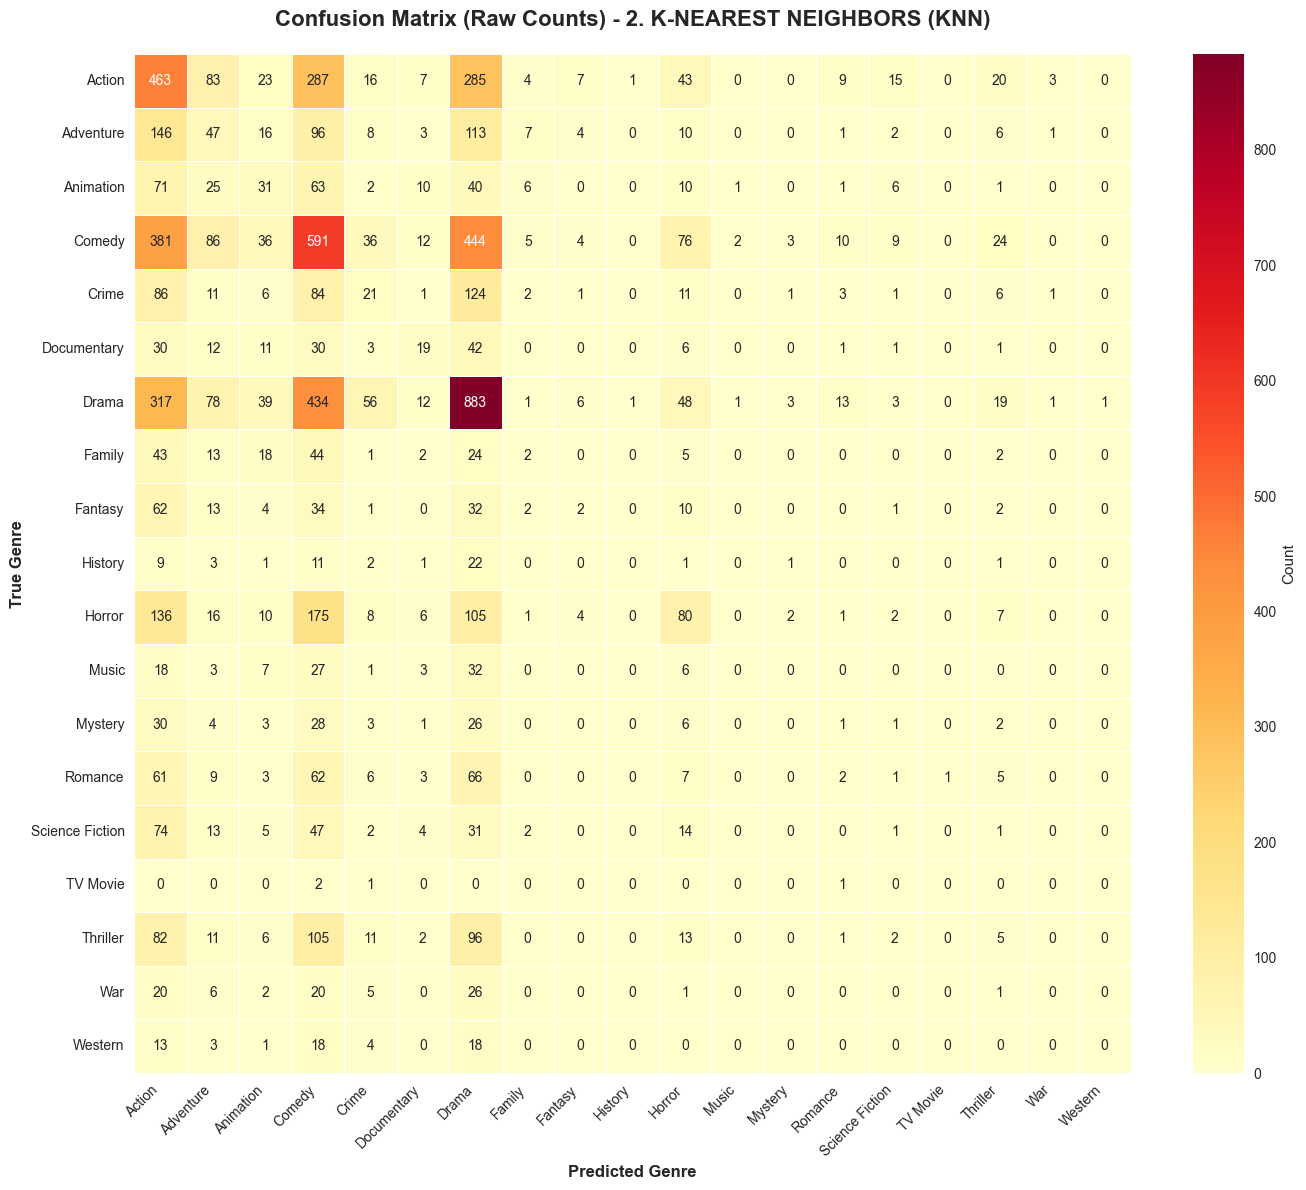

Evaluating on Test Set...
2. KNN (Test Set)

Accuracy: 0.2568

Macro-average Precision: 0.1494
Macro-average Recall: 0.1026
Macro-average F1-score: 0.1045

Per-class metrics:
  Action          - P: 0.2330, R: 0.4046, F1: 0.2957
  Adventure       - P: 0.0789, R: 0.0811, F1: 0.0800
  Animation       - P: 0.2182, R: 0.1579, F1: 0.1832
  Comedy          - P: 0.2593, R: 0.3702, F1: 0.3050
  Crime           - P: 0.0652, R: 0.0312, F1: 0.0423
  Documentary     - P: 0.3077, R: 0.1739, F1: 0.2222
  Drama           - P: 0.3322, R: 0.3849, F1: 0.3566
  Family          - P: 0.1429, R: 0.0238, F1: 0.0408
  Fantasy         - P: 0.2222, R: 0.0392, F1: 0.0667
  History         - P: 0.0000, R: 0.0000, F1: 0.0000
  Horror          - P: 0.3095, R: 0.1793, F1: 0.2271
  Music           - P: 0.0000, R: 0.0000, F1: 0.0000
  Mystery         - P: 0.0000, R: 0.0000, F1: 0.0000
  Romance         - P: 0.3333, R: 0.0132, F1: 0.0253
  Science Fiction - P: 0.0000, R: 0.0000, F1: 0.0000
  TV Movie        - P: 0.0000,

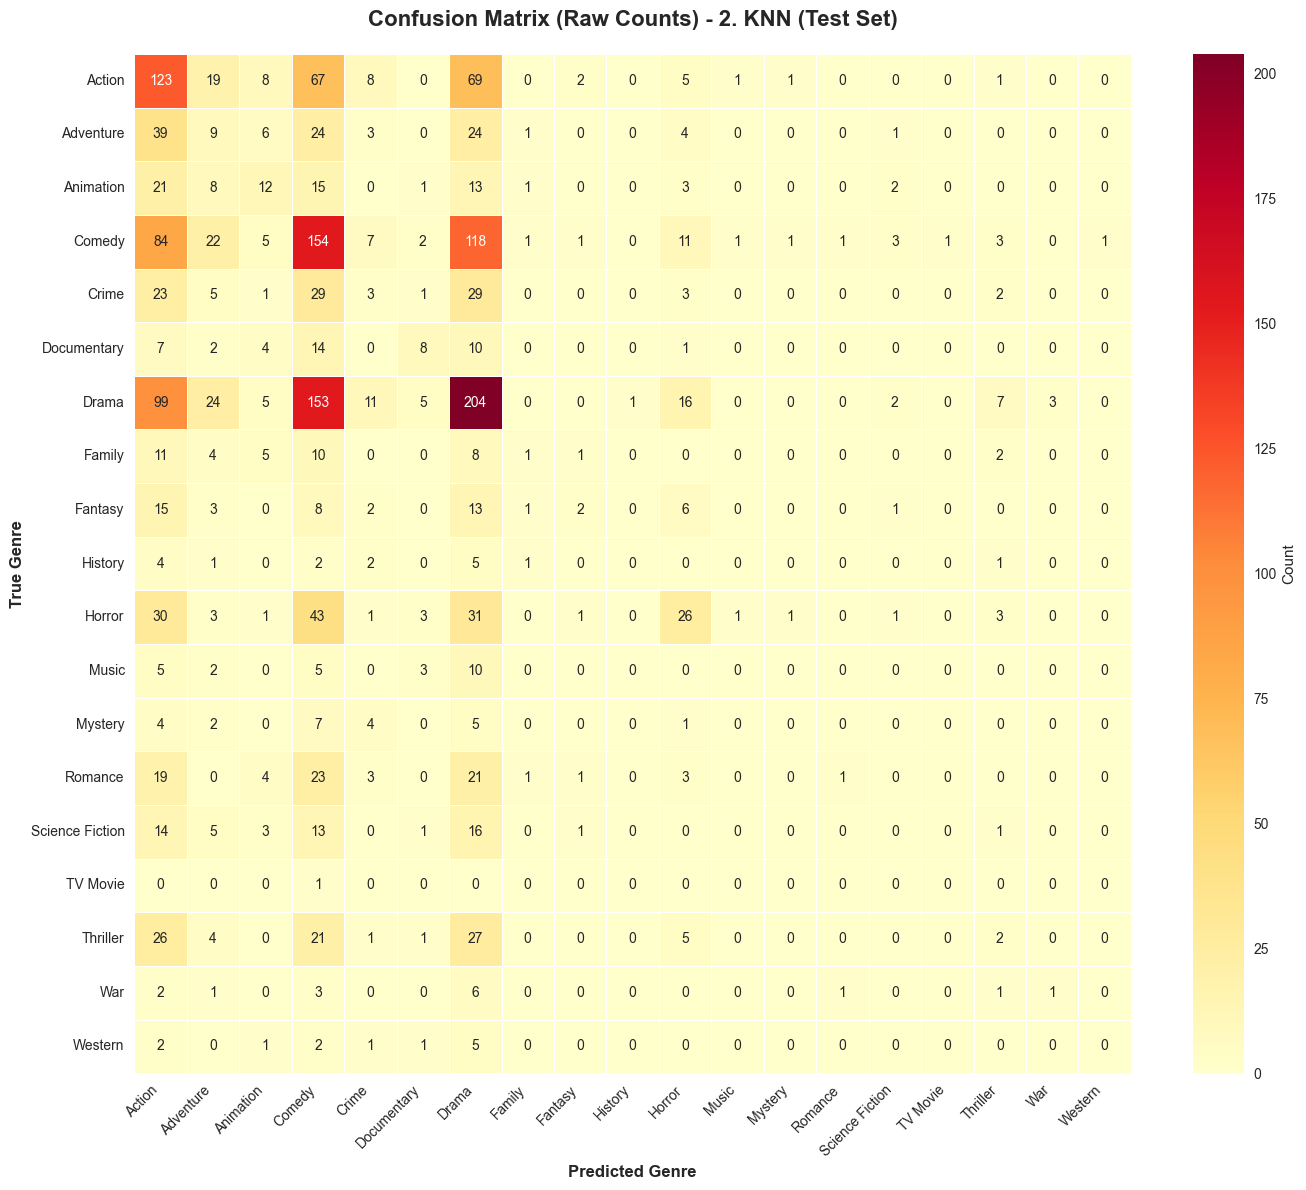

In [273]:
class KNN:
    def __init__(self, n_neighbors=5):
        self.k = n_neighbors
        self.X_train = None
        self.y_train = None
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
    def predict(self, X):
        predictions = np.zeros(X.shape[0], dtype=np.int32)
        for i in range(X.shape[0]):
            distances = np.sqrt(np.sum((self.X_train - X[i]) ** 2, axis=1))
            k_indices = np.argsort(distances)[:self.k]
            k_labels = self.y_train[k_indices]
            predictions[i] = np.bincount(k_labels).argmax()
        return predictions
print("\nTraining KNN Classifier (k=5)...")
knn_results = kfold_cv_classification(X_train, y_genre, KNN, k=5, n_neighbors=5)
print_classification_results("2. K-NEAREST NEIGHBORS (KNN)", knn_results, unique_genres)
print("Evaluating on Test Set...")
model_knn = KNN(n_neighbors=5)
model_knn.fit(X_train, y_genre)
y_pred_test = model_knn.predict(X_test)
n_classes = len(unique_genres)
knn_test_results = {
    "accuracy": compute_accuracy(y_genre_test, y_pred_test),
    "precision": compute_precision_recall_f1(y_genre_test, y_pred_test, n_classes)[0],
    "recall": compute_precision_recall_f1(y_genre_test, y_pred_test, n_classes)[1],
    "f1": compute_precision_recall_f1(y_genre_test, y_pred_test, n_classes)[2],
    "confusion_matrix": compute_confusion_matrix(y_genre_test, y_pred_test, n_classes),
    "y_true": y_genre_test,
    "y_pred": y_pred_test
}
print_classification_results("2. KNN (Test Set)", knn_test_results, unique_genres)

## Decision Tree Classifier



Training Decision Tree Classifier...
3. DECISION TREE CLASSIFIER

Accuracy: 0.3081

Macro-average Precision: 0.1520
Macro-average Recall: 0.1163
Macro-average F1-score: 0.1175

Per-class metrics:
  Action          - P: 0.2588, R: 0.3033, F1: 0.2793
  Adventure       - P: 0.1918, R: 0.0609, F1: 0.0924
  Animation       - P: 0.3200, R: 0.2397, F1: 0.2741
  Comedy          - P: 0.2973, R: 0.4538, F1: 0.3592
  Crime           - P: 0.2712, R: 0.0446, F1: 0.0766
  Documentary     - P: 0.5000, R: 0.2756, F1: 0.3554
  Drama           - P: 0.3525, R: 0.5652, F1: 0.4342
  Family          - P: 0.1739, R: 0.0519, F1: 0.0800
  Fantasy         - P: 0.0500, R: 0.0061, F1: 0.0109
  History         - P: 0.0000, R: 0.0000, F1: 0.0000
  Horror          - P: 0.3112, R: 0.1863, F1: 0.2330
  Music           - P: 0.0000, R: 0.0000, F1: 0.0000
  Mystery         - P: 0.0000, R: 0.0000, F1: 0.0000
  Romance         - P: 0.0000, R: 0.0000, F1: 0.0000
  Science Fiction - P: 0.1200, R: 0.0155, F1: 0.0274
  TV Mov

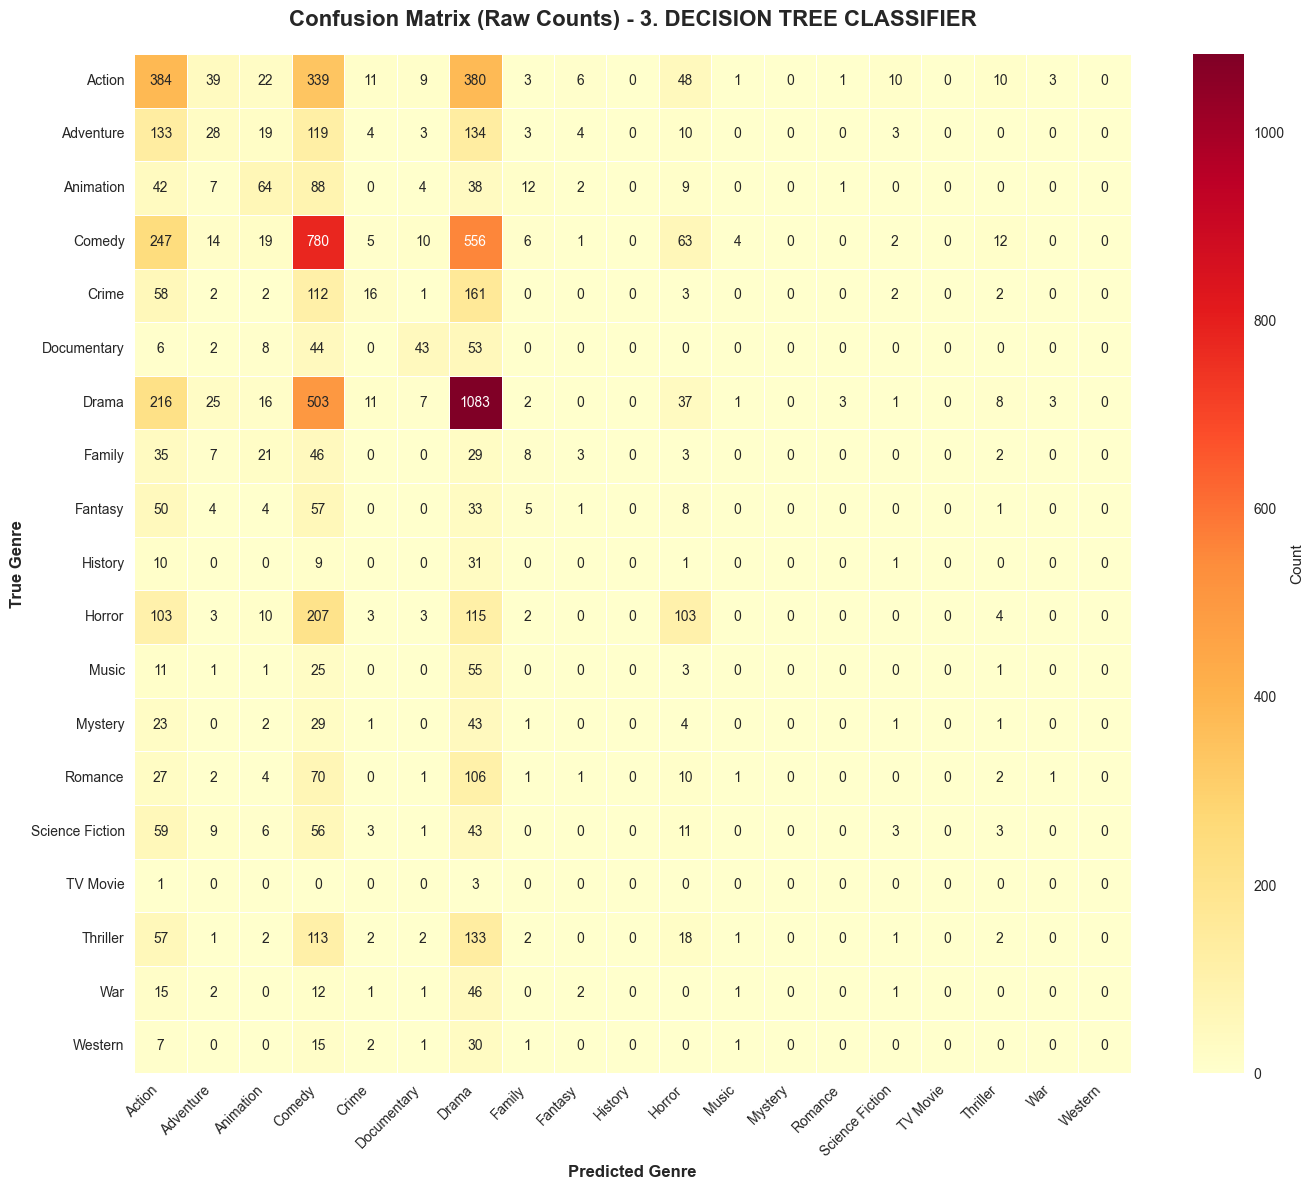

Evaluating on Test Set...
3. DECISION TREE (Test Set)

Accuracy: 0.3137

Macro-average Precision: 0.2121
Macro-average Recall: 0.1174
Macro-average F1-score: 0.1195

Per-class metrics:
  Action          - P: 0.2682, R: 0.4243, F1: 0.3287
  Adventure       - P: 0.1852, R: 0.0450, F1: 0.0725
  Animation       - P: 0.3913, R: 0.2368, F1: 0.2951
  Comedy          - P: 0.2808, R: 0.3942, F1: 0.3280
  Crime           - P: 0.2222, R: 0.0208, F1: 0.0381
  Documentary     - P: 0.8000, R: 0.2609, F1: 0.3934
  Drama           - P: 0.3549, R: 0.5792, F1: 0.4401
  Family          - P: 0.1765, R: 0.0714, F1: 0.1017
  Fantasy         - P: 0.0000, R: 0.0000, F1: 0.0000
  History         - P: 0.0000, R: 0.0000, F1: 0.0000
  Horror          - P: 0.3514, R: 0.1793, F1: 0.2374
  Music           - P: 0.0000, R: 0.0000, F1: 0.0000
  Mystery         - P: 0.0000, R: 0.0000, F1: 0.0000
  Romance         - P: 0.0000, R: 0.0000, F1: 0.0000
  Science Fiction - P: 1.0000, R: 0.0185, F1: 0.0364
  TV Movie        - 

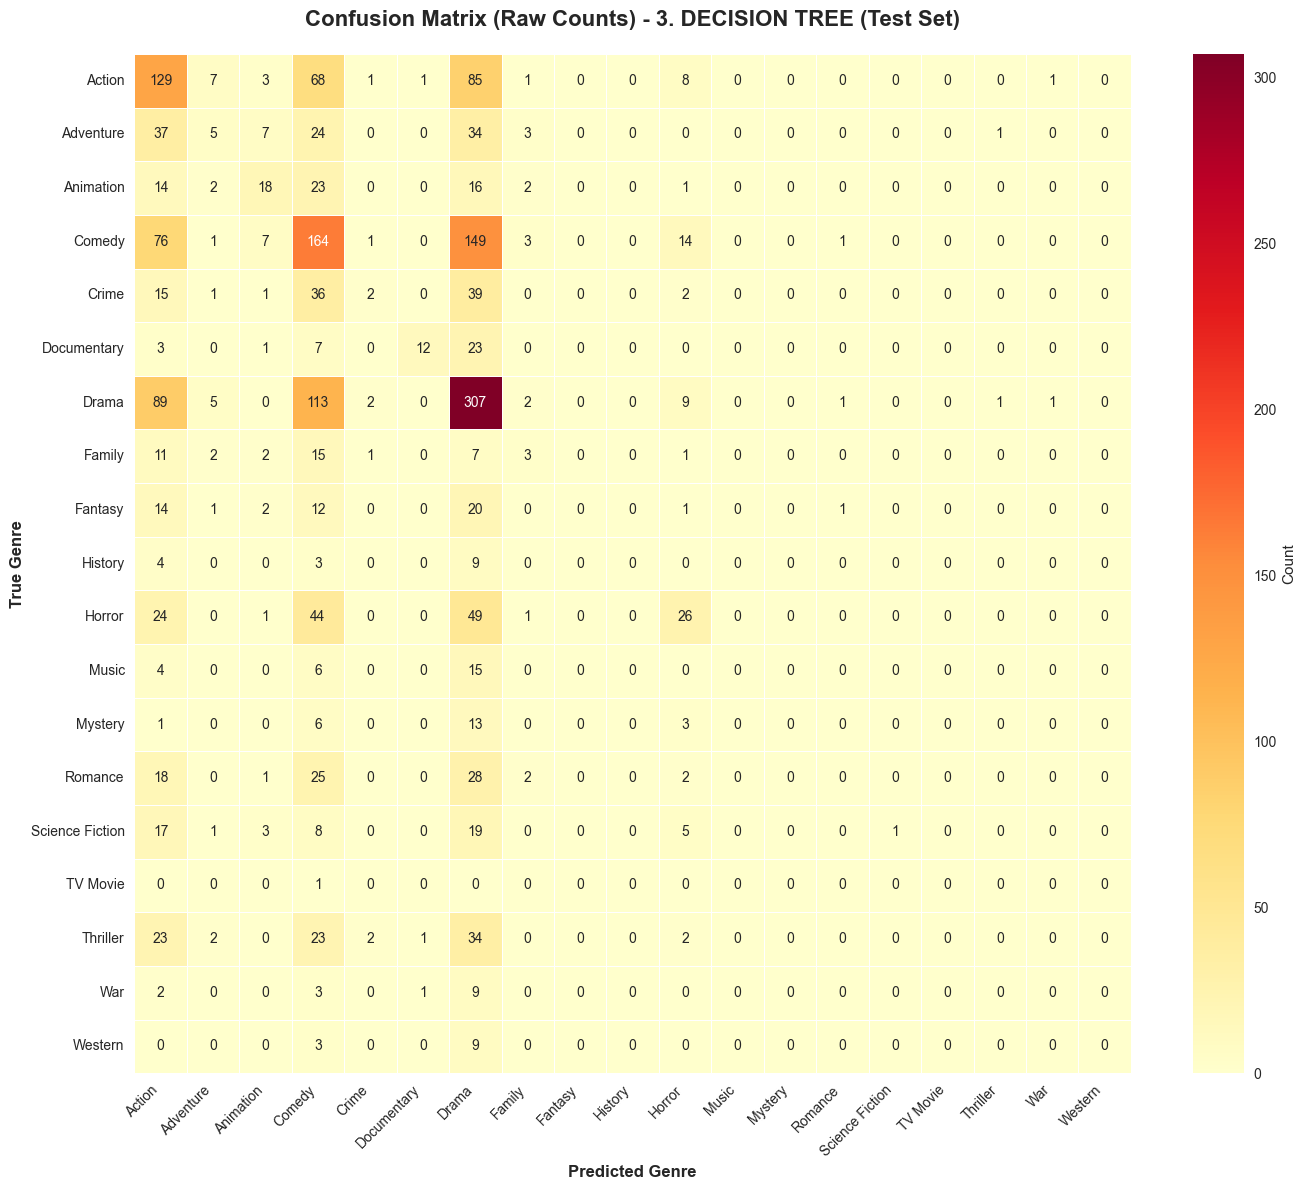

In [274]:
class DecisionTreeClassifier:
    def __init__(self, max_depth=10, min_samples_split=20):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None
    def gini_impurity(self, y):
        if len(y) == 0:
            return 0
        counts = np.bincount(y)
        probs = counts / len(y)
        return 1 - np.sum(probs ** 2)
    def find_best_split(self, X, y):
        best_gini = float('inf')
        best_feature = None
        best_threshold = None
        n_features = X.shape[1]
        for feature_idx in range(n_features):
            feature_values = X[:, feature_idx]
            unique_values = np.unique(feature_values)
            thresholds = (unique_values[:-1] + unique_values[1:]) / 2
            for threshold in thresholds:
                left_mask = feature_values <= threshold
                right_mask = ~left_mask
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue
                left_gini = self.gini_impurity(y[left_mask])
                right_gini = self.gini_impurity(y[right_mask])
                weighted_gini = (np.sum(left_mask) * left_gini + np.sum(right_mask) * right_gini) / len(y)
                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_feature = feature_idx
                    best_threshold = threshold
        return best_feature, best_threshold
    def build_tree(self, X, y, depth=0):
        if depth >= self.max_depth or len(y) < self.min_samples_split or len(np.unique(y)) == 1:
            return np.bincount(y).argmax()
        feature_idx, threshold = self.find_best_split(X, y)
        if feature_idx is None:
            return np.bincount(y).argmax()
        left_mask = X[:, feature_idx] <= threshold
        right_mask = ~left_mask
        if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
            return np.bincount(y).argmax()
        node = {
            'feature': feature_idx,
            'threshold': threshold,
            'left': self.build_tree(X[left_mask], y[left_mask], depth + 1),
            'right': self.build_tree(X[right_mask], y[right_mask], depth + 1)
        }
        return node
    def predict_sample(self, x, node):
        if isinstance(node, dict):
            if x[node['feature']] <= node['threshold']:
                return self.predict_sample(x, node['left'])
            else:
                return self.predict_sample(x, node['right'])
        else:
            return node
    def fit(self, X, y):
        self.tree = self.build_tree(X, y)
    def predict(self, X):
        predictions = np.zeros(X.shape[0], dtype=np.int32)
        for i in range(X.shape[0]):
            predictions[i] = self.predict_sample(X[i], self.tree)
        return predictions
print("\nTraining Decision Tree Classifier...")
dt_results = kfold_cv_classification(X_train, y_genre, DecisionTreeClassifier, k=5, max_depth=10, min_samples_split=20)
print_classification_results("3. DECISION TREE CLASSIFIER", dt_results, unique_genres)
print("Evaluating on Test Set...")
model_dt = DecisionTreeClassifier(max_depth=10, min_samples_split=20)
model_dt.fit(X_train, y_genre)
y_pred_test = model_dt.predict(X_test)
n_classes = len(unique_genres)
dt_test_results = {
    "accuracy": compute_accuracy(y_genre_test, y_pred_test),
    "precision": compute_precision_recall_f1(y_genre_test, y_pred_test, n_classes)[0],
    "recall": compute_precision_recall_f1(y_genre_test, y_pred_test, n_classes)[1],
    "f1": compute_precision_recall_f1(y_genre_test, y_pred_test, n_classes)[2],
    "confusion_matrix": compute_confusion_matrix(y_genre_test, y_pred_test, n_classes),
    "y_true": y_genre_test,
    "y_pred": y_pred_test
}
print_classification_results("3. DECISION TREE (Test Set)", dt_test_results, unique_genres)

## Random Forest Classifier


4. RANDOM FOREST (CV on Train)

Accuracy: 0.2395

Macro-average Precision: 0.0644
Macro-average Recall: 0.0539
Macro-average F1-score: 0.0234

Per-class metrics:
  Action          - P: 0.6364, R: 0.0055, F1: 0.0110
  Adventure       - P: 0.0000, R: 0.0000, F1: 0.0000
  Animation       - P: 0.0000, R: 0.0000, F1: 0.0000
  Comedy          - P: 0.3507, R: 0.0273, F1: 0.0507
  Crime           - P: 0.0000, R: 0.0000, F1: 0.0000
  Documentary     - P: 0.0000, R: 0.0000, F1: 0.0000
  Drama           - P: 0.2371, R: 0.9922, F1: 0.3827
  Family          - P: 0.0000, R: 0.0000, F1: 0.0000
  Fantasy         - P: 0.0000, R: 0.0000, F1: 0.0000
  History         - P: 0.0000, R: 0.0000, F1: 0.0000
  Horror          - P: 0.0000, R: 0.0000, F1: 0.0000
  Music           - P: 0.0000, R: 0.0000, F1: 0.0000
  Mystery         - P: 0.0000, R: 0.0000, F1: 0.0000
  Romance         - P: 0.0000, R: 0.0000, F1: 0.0000
  Science Fiction - P: 0.0000, R: 0.0000, F1: 0.0000
  TV Movie        - P: 0.0000, R: 0.0000, F

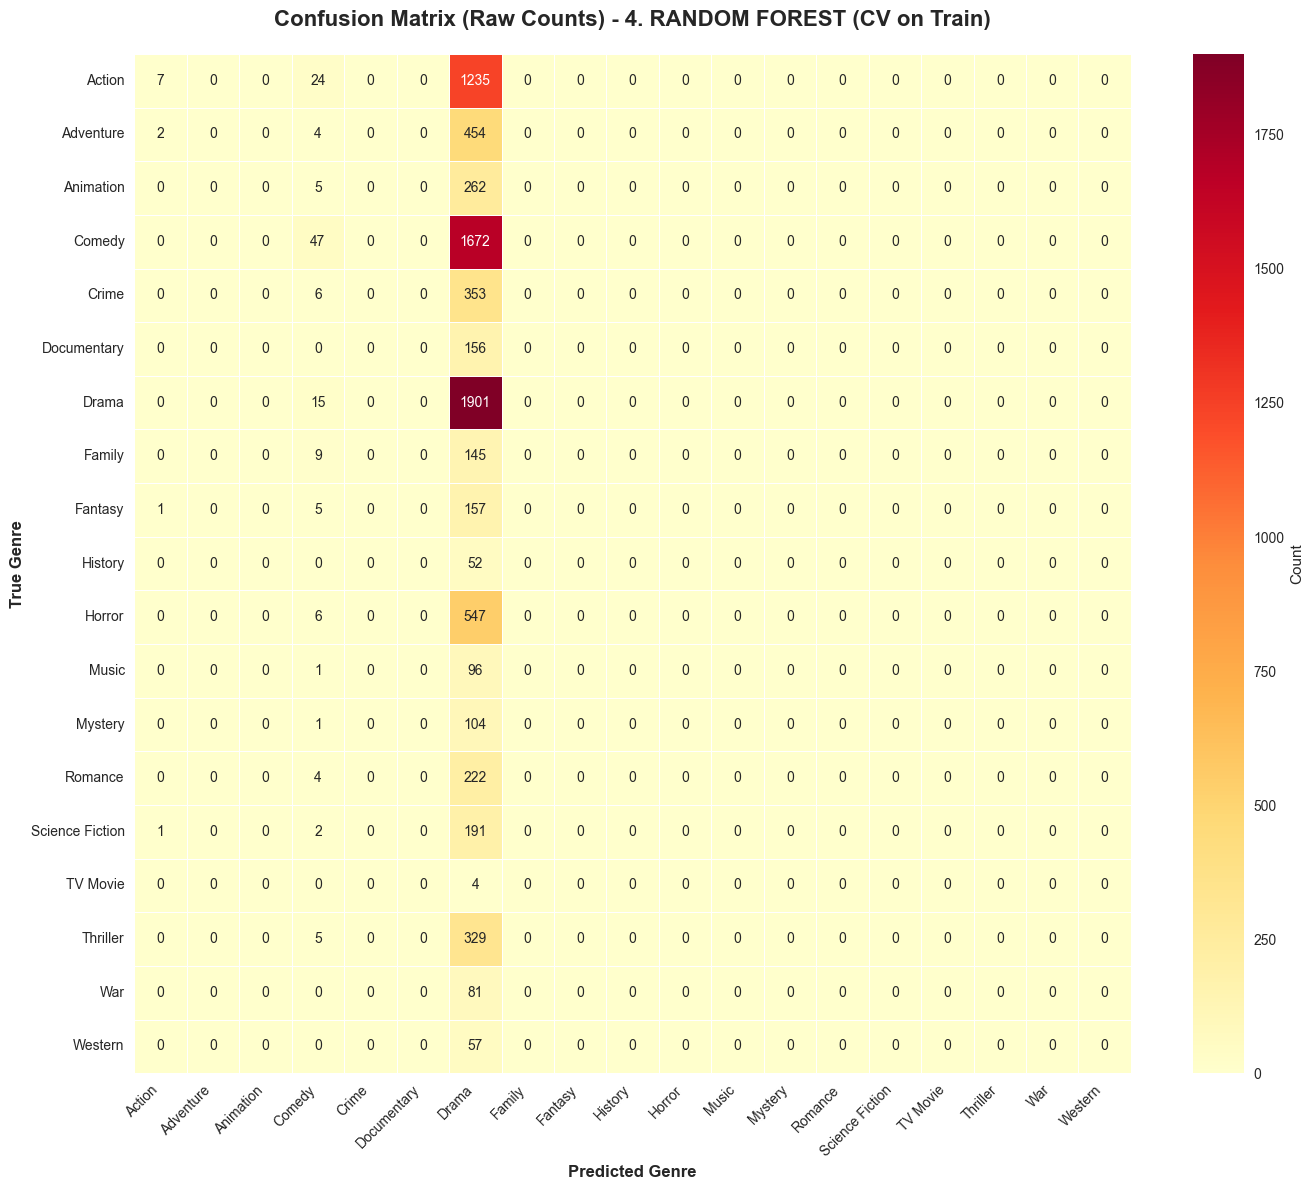

Evaluating on Test Set...
4. RANDOM FOREST (Test Set)

Accuracy: 0.2611

Macro-average Precision: 0.0674
Macro-average Recall: 0.0561
Macro-average F1-score: 0.0284

Per-class metrics:
  Action          - P: 0.6667, R: 0.0066, F1: 0.0130
  Adventure       - P: 0.0000, R: 0.0000, F1: 0.0000
  Animation       - P: 0.0000, R: 0.0000, F1: 0.0000
  Comedy          - P: 0.3571, R: 0.0721, F1: 0.1200
  Crime           - P: 0.0000, R: 0.0000, F1: 0.0000
  Documentary     - P: 0.0000, R: 0.0000, F1: 0.0000
  Drama           - P: 0.2565, R: 0.9868, F1: 0.4072
  Family          - P: 0.0000, R: 0.0000, F1: 0.0000
  Fantasy         - P: 0.0000, R: 0.0000, F1: 0.0000
  History         - P: 0.0000, R: 0.0000, F1: 0.0000
  Horror          - P: 0.0000, R: 0.0000, F1: 0.0000
  Music           - P: 0.0000, R: 0.0000, F1: 0.0000
  Mystery         - P: 0.0000, R: 0.0000, F1: 0.0000
  Romance         - P: 0.0000, R: 0.0000, F1: 0.0000
  Science Fiction - P: 0.0000, R: 0.0000, F1: 0.0000
  TV Movie        - 

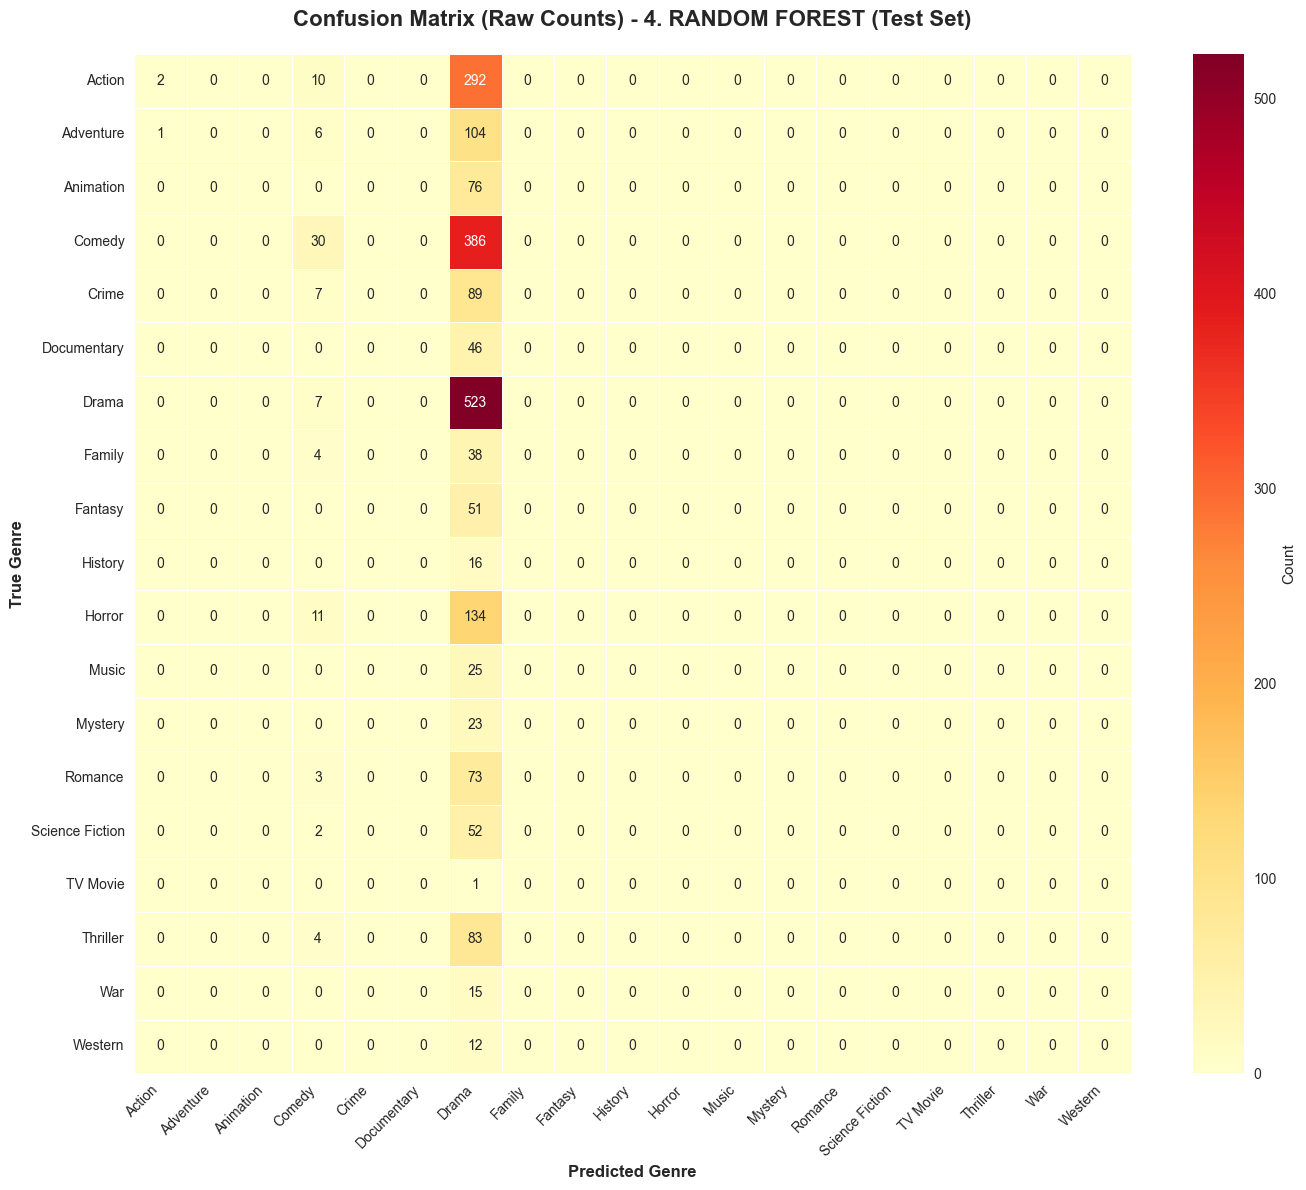

In [275]:
class RandomForestClassifierOptimized:
    def __init__(self, n_estimators=15, max_depth=8, min_samples_split=20, max_features=50):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.trees = []
        self.feature_indices_list = []
    def _bootstrap_sample(self, X, y):
        n_samples = X.shape[0]
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        return X[indices], y[indices]
    def _get_feature_subset(self, n_features):
        if isinstance(self.max_features, str):
            if self.max_features == 'sqrt':
                n_selected = int(np.sqrt(n_features))
            elif self.max_features == 'log2':
                n_selected = int(np.log2(n_features)) + 1
            else:
                n_selected = int(0.3 * n_features)
        else:
            n_selected = self.max_features      
        n_selected = max(1, min(n_selected, n_features))
        selected = np.random.choice(n_features, size=n_selected, replace=False)
        return selected
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.trees = []
        self.feature_indices_list = []
        for i in range(self.n_estimators):
            # Bootstrap sampling
            X_boot, y_boot = self._bootstrap_sample(X, y)      
            # Feature subsampling
            feature_indices = self._get_feature_subset(n_features)
            X_boot_subset = X_boot[:, feature_indices]           
            # Train decision tree on subset
            tree = DecisionTreeClassifier(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split
            )
            tree.fit(X_boot_subset, y_boot)
            self.trees.append(tree)
            self.feature_indices_list.append(feature_indices)
    def predict(self, X):
        n_samples = X.shape[0]
        all_predictions = np.zeros((n_samples, self.n_estimators), dtype=np.int32)
        for i, (tree, feature_indices) in enumerate(zip(self.trees, self.feature_indices_list)):
            X_subset = X[:, feature_indices]
            all_predictions[:, i] = tree.predict(X_subset)
        predictions = np.zeros(n_samples, dtype=np.int32)
        for j in range(n_samples):
            predictions[j] = np.bincount(all_predictions[j, :]).argmax()
        return predictions
rf_results = kfold_cv_classification(X_train, y_genre, RandomForestClassifierOptimized, k=3, 
                                     n_estimators=30, max_depth=15, min_samples_split=20, max_features=60)
print_classification_results("4. RANDOM FOREST (CV on Train)", rf_results, unique_genres)
print("Evaluating on Test Set...")
model_rf = RandomForestClassifierOptimized(n_estimators=30, max_depth=15, min_samples_split=20, max_features=60)
model_rf.fit(X_train, y_genre)
y_pred_test = model_rf.predict(X_test)
n_classes = len(unique_genres)
rf_test_results = {
    "accuracy": compute_accuracy(y_genre_test, y_pred_test),
    "precision": compute_precision_recall_f1(y_genre_test, y_pred_test, n_classes)[0],
    "recall": compute_precision_recall_f1(y_genre_test, y_pred_test, n_classes)[1],
    "f1": compute_precision_recall_f1(y_genre_test, y_pred_test, n_classes)[2],
    "confusion_matrix": compute_confusion_matrix(y_genre_test, y_pred_test, n_classes),
    "y_true": y_genre_test,
    "y_pred": y_pred_test
}
print_classification_results("4. RANDOM FOREST (Test Set)", rf_test_results, unique_genres)

# Regression Models - Revenue Prediction

## Regression Metrics

In [276]:
def compute_mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))
def compute_rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))
def compute_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return 0.0
    return 1 - (ss_res / ss_tot)
def kfold_cv_regression(X, y, model_class, k=5, **model_params):
    n_samples = len(X)
    fold_size = n_samples // k
    indices = np.arange(n_samples)
    np.random.shuffle(indices) 
    all_mae = []
    all_rmse = []
    all_r2 = []
    all_y_true = []
    all_y_pred = []
    for i in range(k):
        start = i * fold_size
        end = (i + 1) * fold_size if i < k - 1 else n_samples
        val_indices = indices[start:end]
        train_indices = np.concatenate([indices[:start], indices[end:]])
        X_train_fold, X_val_fold = X[train_indices], X[val_indices]
        y_train_fold, y_val_fold = y[train_indices], y[val_indices]
        model = model_class(**model_params)
        model.fit(X_train_fold, y_train_fold)
        y_pred = model.predict(X_val_fold)
        all_mae.append(compute_mae(y_val_fold, y_pred))
        all_rmse.append(compute_rmse(y_val_fold, y_pred))
        all_r2.append(compute_r2(y_val_fold, y_pred))
        all_y_true.extend(y_val_fold)
        all_y_pred.extend(y_pred)
    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)
    return {
        "mae": np.mean(all_mae),
        "rmse": np.mean(all_rmse),
        "r2": np.mean(all_r2),
        "mae_std": np.std(all_mae),
        "rmse_std": np.std(all_rmse),
        "r2_std": np.std(all_r2),
        "y_true": all_y_true,
        "y_pred": all_y_pred
    }
def print_regression_results(model_name, results):
    print(f"{model_name}")
    print(f"\nMean Absolute Error (MAE):     {results['mae']:.2f} ± {results['mae_std']:.2f}")
    print(f"Root Mean Squared Error (RMSE): {results['rmse']:.2f} ± {results['rmse_std']:.2f}")
    print(f"R-squared (R²):                 {results['r2']:.4f} ± {results['r2_std']:.4f}")

## Linear Regression

In [277]:
class LinearRegression:
    def __init__(self, learning_rate=0.01, max_iter=1000, tol=1e-6):
        self.lr = learning_rate
        self.max_iter = max_iter
        self.tol = tol
        self.weights = None
        self.bias = None
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        for i in range(self.max_iter):
            # Predictions
            y_pred = X @ self.weights + self.bias
            # Compute gradients
            error = y_pred - y
            grad_weights = (X.T @ error) / n_samples
            grad_bias = np.mean(error)
            # Update parameters
            prev_weights = self.weights.copy()
            self.weights -= self.lr * grad_weights
            self.bias -= self.lr * grad_bias 
            # Check for convergence
            weight_change = np.linalg.norm(self.weights - prev_weights)
            if weight_change < self.tol:
                break
    def predict(self, X):
        return X @ self.weights + self.bias
print("\nTraining Linear Regression Model...")
lr_reg_results = kfold_cv_regression(X_train, y_revenue, LinearRegression, k=5, 
                                     learning_rate=0.01, max_iter=1000)
print_regression_results("1. LINEAR REGRESSION (CV on Train)", lr_reg_results)
print("Evaluating on Test Set...")
model_lr_reg = LinearRegression(learning_rate=0.01, max_iter=1000)
model_lr_reg.fit(X_train, y_revenue)
y_pred_test = model_lr_reg.predict(X_test)
y_revenue_test = test_df["revenue"].to_numpy(dtype=np.float32)
lr_reg_test_results = {
    "mae": compute_mae(y_revenue_test, y_pred_test),
    "rmse": compute_rmse(y_revenue_test, y_pred_test),
    "r2": compute_r2(y_revenue_test, y_pred_test),
    "mae_std": 0.0,
    "rmse_std": 0.0,
    "r2_std": 0.0,
    "y_true": y_revenue_test,
    "y_pred": y_pred_test
}
print_regression_results("1. LINEAR REGRESSION (Test Set)", lr_reg_test_results)


Training Linear Regression Model...
1. LINEAR REGRESSION (CV on Train)

Mean Absolute Error (MAE):     39120561.67 ± 2172709.84
Root Mean Squared Error (RMSE): 83753616.13 ± 8440264.56
R-squared (R²):                 0.6911 ± 0.0271
Evaluating on Test Set...
1. LINEAR REGRESSION (Test Set)

Mean Absolute Error (MAE):     39213751.81 ± 0.00
Root Mean Squared Error (RMSE): 95939331.25 ± 0.00
R-squared (R²):                 0.6892 ± 0.0000


## Decision Tree Regressor

In [283]:
class DecisionTreeRegressor:
    def __init__(self, max_depth=10, min_samples_split=20):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None
    def _compute_variance(self, y):
        if len(y) == 0:
            return 0
        return np.var(y)
    def _find_best_split(self, X, y):
        best_variance_reduction = -float('inf')
        best_feature = None
        best_threshold = None
        n_features = X.shape[1]
        for feature_idx in range(n_features):
            feature_values = X[:, feature_idx]
            unique_values = np.unique(feature_values)
            thresholds = (unique_values[:-1] + unique_values[1:]) / 2
            for threshold in thresholds:
                left_mask = feature_values <= threshold
                right_mask = ~left_mask
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue
                left_variance = self._compute_variance(y[left_mask])
                right_variance = self._compute_variance(y[right_mask])
                n_left = np.sum(left_mask)
                n_right = np.sum(right_mask)
                n_total = len(y)
                weighted_variance = (n_left * left_variance + n_right * right_variance) / n_total
                parent_variance = self._compute_variance(y)
                variance_reduction = parent_variance - weighted_variance
                if variance_reduction > best_variance_reduction:
                    best_variance_reduction = variance_reduction
                    best_feature = feature_idx
                    best_threshold = threshold
        return best_feature, best_threshold
    def _build_tree(self, X, y, depth=0):
        if depth >= self.max_depth or len(y) < self.min_samples_split:
            return np.mean(y) 
        feature_idx, threshold = self._find_best_split(X, y)
        if feature_idx is None:
            return np.mean(y)
        left_mask = X[:, feature_idx] <= threshold
        right_mask = ~left_mask
        if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
            return np.mean(y)
        node = {
            'feature': feature_idx,
            'threshold': threshold,
            'left': self._build_tree(X[left_mask], y[left_mask], depth + 1),
            'right': self._build_tree(X[right_mask], y[right_mask], depth + 1)
        }
        return node
    def _predict_sample(self, x, node):
        if isinstance(node, dict):
            if x[node['feature']] <= node['threshold']:
                return self._predict_sample(x, node['left'])
            else:
                return self._predict_sample(x, node['right'])
        else:
            return node
    def fit(self, X, y):
        self.tree = self._build_tree(X, y)
    def predict(self, X):
        predictions = np.zeros(X.shape[0], dtype=np.float32)
        for i in range(X.shape[0]):
            predictions[i] = self._predict_sample(X[i], self.tree)
        return predictions
print("\nTraining Decision Tree Regressor...")
dt_reg_results = kfold_cv_regression(X_train, y_revenue, DecisionTreeRegressor, k=3, 
                                     max_depth=10, min_samples_split=20)
print_regression_results("2. DECISION TREE REGRESSOR (CV on Train)", dt_reg_results)
print("Evaluating on Test Set...")
model_dt_reg = DecisionTreeRegressor(max_depth=10, min_samples_split=20)
model_dt_reg.fit(X_train, y_revenue)
y_pred_test = model_dt_reg.predict(X_test)
y_revenue_test = test_df["revenue"].to_numpy(dtype=np.float32)
dt_reg_test_results = {
    "mae": compute_mae(y_revenue_test, y_pred_test),
    "rmse": compute_rmse(y_revenue_test, y_pred_test),
    "r2": compute_r2(y_revenue_test, y_pred_test),
    "mae_std": 0.0,
    "rmse_std": 0.0,
    "r2_std": 0.0,
    "y_true": y_revenue_test,
    "y_pred": y_pred_test
}
print_regression_results("2. DECISION TREE REGRESSOR (Test Set)", dt_reg_test_results)


Training Decision Tree Regressor...
2. DECISION TREE REGRESSOR (CV on Train)

Mean Absolute Error (MAE):     39839996.00 ± 2207416.50
Root Mean Squared Error (RMSE): 104163392.00 ± 4582511.50
R-squared (R²):                 0.5132 ± 0.0804
Evaluating on Test Set...
2. DECISION TREE REGRESSOR (Test Set)

Mean Absolute Error (MAE):     38606724.00 ± 0.00
Root Mean Squared Error (RMSE): 105839328.00 ± 0.00
R-squared (R²):                 0.6217 ± 0.0000


## Random Forest Regressor

In [286]:
class RandomForestRegressor:
    def __init__(self, n_estimators=15, max_depth=8, min_samples_split=20, max_features=50):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.trees = []
        self.feature_indices_list = []
    def _bootstrap_sample(self, X, y):
        n_samples = X.shape[0]
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        return X[indices], y[indices]
    def _get_feature_subset(self, n_features):
        if isinstance(self.max_features, str):
            if self.max_features == 'sqrt':
                n_selected = int(np.sqrt(n_features))
            elif self.max_features == 'log2':
                n_selected = int(np.log2(n_features)) + 1
            else:
                n_selected = int(0.3 * n_features)
        else:
            n_selected = self.max_features
        n_selected = max(1, min(n_selected, n_features))
        selected = np.random.choice(n_features, size=n_selected, replace=False)
        return selected
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.trees = []
        self.feature_indices_list = []
        for i in range(self.n_estimators):
            # Bootstrap sampling
            X_boot, y_boot = self._bootstrap_sample(X, y)
            # Feature subsampling
            feature_indices = self._get_feature_subset(n_features)
            X_boot_subset = X_boot[:, feature_indices]
            
            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split
            )
            tree.fit(X_boot_subset, y_boot)
            self.trees.append(tree)
            self.feature_indices_list.append(feature_indices)
    def predict(self, X):
        n_samples = X.shape[0]
        all_predictions = np.zeros((n_samples, self.n_estimators), dtype=np.float32)
        for i, (tree, feature_indices) in enumerate(zip(self.trees, self.feature_indices_list)):
            X_subset = X[:, feature_indices]
            all_predictions[:, i] = tree.predict(X_subset)
        # Average predictions from all trees
        predictions = np.mean(all_predictions, axis=1)
        return predictions
print("\nTraining Random Forest Regressor...")
rf_reg_results = kfold_cv_regression(X_train, y_revenue, RandomForestRegressor, k=3, 
                                     n_estimators=20, max_depth=12, min_samples_split=15, max_features=80)
print_regression_results("3. RANDOM FOREST REGRESSOR (CV on Train)", rf_reg_results)
print("Evaluating on Test Set...")
model_rf_reg = RandomForestRegressor(n_estimators=20, max_depth=12, min_samples_split=15, max_features=80)
model_rf_reg.fit(X_train, y_revenue)
y_pred_test = model_rf_reg.predict(X_test)
y_revenue_test = test_df["revenue"].to_numpy(dtype=np.float32)
rf_reg_test_results = {
    "mae": compute_mae(y_revenue_test, y_pred_test),
    "rmse": compute_rmse(y_revenue_test, y_pred_test),
    "r2": compute_r2(y_revenue_test, y_pred_test),
    "mae_std": 0.0,
    "rmse_std": 0.0,
    "r2_std": 0.0,
    "y_true": y_revenue_test,
    "y_pred": y_pred_test
}
print_regression_results("3. RANDOM FOREST REGRESSOR (Test Set)", rf_reg_test_results)


Training Random Forest Regressor...
3. RANDOM FOREST REGRESSOR (CV on Train)

Mean Absolute Error (MAE):     66747312.00 ± 1187812.38
Root Mean Squared Error (RMSE): 131121288.00 ± 5876086.00
R-squared (R²):                 0.2500 ± 0.0147
Evaluating on Test Set...
3. RANDOM FOREST REGRESSOR (Test Set)

Mean Absolute Error (MAE):     72981736.00 ± 0.00
Root Mean Squared Error (RMSE): 157434624.00 ± 0.00
R-squared (R²):                 0.1630 ± 0.0000


## Evaluation and Performance Analysis

In [287]:
def get_macro_avg(metric_array):
    if metric_array is None:
        return None
    if isinstance(metric_array, (list, np.ndarray)):
        valid_values = [v for v in metric_array if not (np.isnan(v) or v == 0)]
        if len(valid_values) > 0:
            return np.mean(valid_values)
        return 0.0
    return float(metric_array)
classification_models = {
    "Logistic Regression": {
        "CV": lr_results if 'lr_results' in globals() else None,
        "Test": lr_test_results if 'lr_test_results' in globals() else None
    },
    "K-Nearest Neighbors (KNN)": {
        "CV": knn_results if 'knn_results' in globals() else None,
        "Test": knn_test_results if 'knn_test_results' in globals() else None
    },
    "Decision Tree Classifier": {
        "CV": dt_results if 'dt_results' in globals() else None,
        "Test": dt_test_results if 'dt_test_results' in globals() else None
    },
    "Random Forest Classifier": {
        "CV": rf_results if 'rf_results' in globals() else None,
        "Test": rf_test_results if 'rf_test_results' in globals() else None
    }
}
classification_data = []
for model_name, results in classification_models.items():
    row = {"Model": model_name}
    if results["CV"] is not None:
        row["CV_Accuracy"] = float(results["CV"].get("accuracy", 0))
        row["CV_Macro_Precision"] = get_macro_avg(results["CV"].get("precision", None))
        row["CV_Macro_Recall"] = get_macro_avg(results["CV"].get("recall", None))
        row["CV_Macro_F1"] = get_macro_avg(results["CV"].get("f1", None))
    else:
        row["CV_Accuracy"] = row["CV_Macro_Precision"] = row["CV_Macro_Recall"] = row["CV_Macro_F1"] = None
    if results["Test"] is not None:
        row["Test_Accuracy"] = float(results["Test"].get("accuracy", 0))
        row["Test_Macro_Precision"] = get_macro_avg(results["Test"].get("precision", None))
        row["Test_Macro_Recall"] = get_macro_avg(results["Test"].get("recall", None))
        row["Test_Macro_F1"] = get_macro_avg(results["Test"].get("f1", None))
    else:
        row["Test_Accuracy"] = row["Test_Macro_Precision"] = row["Test_Macro_Recall"] = row["Test_Macro_F1"] = None
    classification_data.append(row)
df_classification = pd.DataFrame(classification_data)
print("\nCLASSIFICATION MODELS PERFORMANCE TABLE")
print("-"*80)
display_cols = ["Model", "CV_Accuracy", "CV_Macro_Precision", "CV_Macro_Recall", "CV_Macro_F1",
                "Test_Accuracy", "Test_Macro_Precision", "Test_Macro_Recall", "Test_Macro_F1"]
print(df_classification[display_cols].to_string(index=False, float_format='%.4f'))
print("-"*80)
if not df_classification["Test_Accuracy"].isna().all():
    best_classification_idx = df_classification["Test_Accuracy"].idxmax()
    best_classification_model = df_classification.loc[best_classification_idx, "Model"]
    best_classification_accuracy = float(df_classification.loc[best_classification_idx, "Test_Accuracy"])
    best_classification_precision = float(df_classification.loc[best_classification_idx, "Test_Macro_Precision"]) if df_classification.loc[best_classification_idx, "Test_Macro_Precision"] is not None else None
    best_classification_recall = float(df_classification.loc[best_classification_idx, "Test_Macro_Recall"]) if df_classification.loc[best_classification_idx, "Test_Macro_Recall"] is not None else None
    best_classification_f1 = float(df_classification.loc[best_classification_idx, "Test_Macro_F1"]) if df_classification.loc[best_classification_idx, "Test_Macro_F1"] is not None else None
    print(f"\nBEST CLASSIFICATION MODEL: {best_classification_model}")
    print(f"   Test Accuracy: {best_classification_accuracy:.4f} ({best_classification_accuracy*100:.2f}%)")
    if best_classification_precision is not None:
        print(f"   Test Macro-Averaged Precision: {best_classification_precision:.4f}")
    if best_classification_recall is not None:
        print(f"   Test Macro-Averaged Recall: {best_classification_recall:.4f}")
    if best_classification_f1 is not None:
        print(f"   Test Macro-Averaged F1-Score: {best_classification_f1:.4f}")
regression_models = {
    "Linear Regression": {
        "CV": lr_reg_results if 'lr_reg_results' in globals() else None,
        "Test": lr_reg_test_results if 'lr_reg_test_results' in globals() else None
    },
    "Decision Tree Regressor": {
        "CV": dt_reg_results if 'dt_reg_results' in globals() else None,
        "Test": dt_reg_test_results if 'dt_reg_test_results' in globals() else None
    },
    "Random Forest Regressor": {
        "CV": rf_reg_results if 'rf_reg_results' in globals() else None,
        "Test": rf_reg_test_results if 'rf_reg_test_results' in globals() else None
    }
}
regression_data = []
for model_name, results in regression_models.items():
    row = {"Model": model_name}
    if results["CV"] is not None:
        row["CV_MAE"] = float(results["CV"].get("mae", 0))
        row["CV_RMSE"] = float(results["CV"].get("rmse", 0))
        row["CV_R2"] = float(results["CV"].get("r2", 0))
    else:
        row["CV_MAE"] = row["CV_RMSE"] = row["CV_R2"] = None
    if results["Test"] is not None:
        row["Test_MAE"] = float(results["Test"].get("mae", 0))
        row["Test_RMSE"] = float(results["Test"].get("rmse", 0))
        row["Test_R2"] = float(results["Test"].get("r2", 0))
    else:
        row["Test_MAE"] = row["Test_RMSE"] = row["Test_R2"] = None
    regression_data.append(row)
df_regression = pd.DataFrame(regression_data)
print("\nREGRESSION MODELS PERFORMANCE TABLE")
print("-"*80)
display_cols_reg = ["Model", "CV_MAE", "CV_RMSE", "CV_R2", "Test_MAE", "Test_RMSE", "Test_R2"]
print(df_regression[display_cols_reg].to_string(index=False, float_format='%.2f'))
print("-"*80)
if not df_regression["Test_R2"].isna().all():
    best_regression_idx = df_regression["Test_R2"].idxmax()
    best_regression_model = df_regression.loc[best_regression_idx, "Model"]
    best_regression_r2 = float(df_regression.loc[best_regression_idx, "Test_R2"])
    best_regression_mae = float(df_regression.loc[best_regression_idx, "Test_MAE"])
    best_regression_rmse = float(df_regression.loc[best_regression_idx, "Test_RMSE"])
    print(f"\n BEST REGRESSION MODEL: {best_regression_model}")
    print(f"   Test R²: {best_regression_r2:.4f} ({best_regression_r2*100:.2f}%)")
    print(f"   Test MAE: {best_regression_mae:,.2f}")
    print(f"   Test RMSE: {best_regression_rmse:,.2f}")


CLASSIFICATION MODELS PERFORMANCE TABLE
--------------------------------------------------------------------------------
                    Model  CV_Accuracy  CV_Macro_Precision  CV_Macro_Recall  CV_Macro_F1  Test_Accuracy  Test_Macro_Precision  Test_Macro_Recall  Test_Macro_F1
      Logistic Regression       0.2887              0.2415           0.3380       0.2494         0.2752                0.2607             0.4227         0.3098
K-Nearest Neighbors (KNN)       0.2630              0.1483           0.1360       0.1327         0.2568                0.2184             0.1499         0.1528
 Decision Tree Classifier       0.3081              0.2407           0.1841       0.1861         0.3137                0.4030             0.2231         0.2271
 Random Forest Classifier       0.2395              0.4081           0.3417       0.1481         0.2611                0.4268             0.3552         0.1801
------------------------------------------------------------------------------

# Tiny ML Conversion

In [280]:
import tensorflow as tf
import time
import os
print("\n1. Extracting weights from trained NumPy Linear Regression model...")
numpy_weights = model_lr_reg.weights.copy()
numpy_bias = model_lr_reg.bias
print(f"   Weights shape: {numpy_weights.shape}")
print(f"   Bias value: {numpy_bias:.6f}")
print(f"   Input features: {X_train.shape[1]}")
# Recreate the same model architecture in TensorFlow
print("\n2. Recreating Linear Regression model in TensorFlow...")
tf_model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=(X_train.shape[1],), use_bias=True, name='linear_regression')
])
# Load NumPy-trained weights into TensorFlow model
print("3. Loading NumPy-trained weights into TensorFlow model...")
tf_model.layers[0].set_weights([numpy_weights.reshape(-1, 1), np.array([numpy_bias])])
print(f"   TensorFlow model created with loaded weights")
print(f"   TensorFlow weights shape: {tf_model.layers[0].get_weights()[0].shape}")
print(f"   TensorFlow bias: {tf_model.layers[0].get_weights()[1][0]:.6f}")
weights_match = np.allclose(tf_model.layers[0].get_weights()[0].flatten(), numpy_weights, atol=1e-5)
bias_match = np.allclose(tf_model.layers[0].get_weights()[1][0], numpy_bias, atol=1e-5)
print(f"   Weights match: {weights_match}")
print(f"   Bias match: {bias_match}")
# Evaluate TensorFlow model (should match NumPy model)
print("\n4. Evaluating TensorFlow model...")
y_pred_tf = tf_model.predict(X_test, verbose=0).flatten()
mae_tf = compute_mae(y_revenue_test, y_pred_tf)
rmse_tf = compute_rmse(y_revenue_test, y_pred_tf)
r2_tf = compute_r2(y_revenue_test, y_pred_tf)
print(f"   MAE:  {mae_tf:,.2f}")
print(f"   RMSE: {rmse_tf:,.2f}")
print(f"   R²:   {r2_tf:.4f}")
# Compare with original NumPy model
print(f"\n   Original NumPy Model:")
print(f"   MAE:  {lr_reg_test_results['mae']:,.2f}")
print(f"   RMSE: {lr_reg_test_results['rmse']:,.2f}")
print(f"   R²:   {lr_reg_test_results['r2']:.4f}")
# Convert to TensorFlow Lite
print("\n5. Converting to TensorFlow Lite (TFLite)...")
# Create TFLite converter
converter = tf.lite.TFLiteConverter.from_keras_model(tf_model)
# Optimize for size and speed
converter.optimizations = [tf.lite.Optimize.DEFAULT]
# Convert
tflite_model = converter.convert()
# Save TFLite model
tflite_model_path = "linear_regression.tflite"
with open(tflite_model_path, 'wb') as f:
    f.write(tflite_model)
print(f"   TFLite model saved: {tflite_model_path}")
# Evaluate model size
tflite_size = os.path.getsize(tflite_model_path) / (1024 * 1024)  
tflite_size_kb = tflite_size * 1024
print(f"\n6. Model Size Comparison:")
print(f"   TFLite model size: {tflite_size:.4f} MB ({tflite_size_kb:.2f} KB)")
# Estimate original model size (weights + bias)
original_weights_size = (numpy_weights.nbytes + 8) / (1024 * 1024) 
print(f"   Estimated NumPy model size: {original_weights_size:.4f} MB")
print(f"   Size reduction: {((original_weights_size - tflite_size) / original_weights_size * 100):.2f}%")
# Evaluate inference speed
print("\n7. Inference Speed Comparison:")
# NumPy model inference
start_time = time.time()
for _ in range(100):
    _ = model_lr_reg.predict(X_test[:10])
numpy_time = (time.time() - start_time) / 100
print(f"   NumPy model: {numpy_time*1000:.2f} ms per prediction (avg of 100 runs)")
# TensorFlow model inference
start_time = time.time()
for _ in range(100):
    _ = tf_model.predict(X_test[:10], verbose=0)
tf_time = (time.time() - start_time) / 100
print(f"   TensorFlow model: {tf_time*1000:.2f} ms per prediction (avg of 100 runs)")
# TFLite model inference
interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
start_time = time.time()
for _ in range(100):
    sample = X_test[0:1].astype(np.float32) 
    interpreter.set_tensor(input_details[0]['index'], sample)
    interpreter.invoke()
    _ = interpreter.get_tensor(output_details[0]['index'])
tflite_time = (time.time() - start_time) / 100
print(f"   TFLite model: {tflite_time*1000:.2f} ms per prediction (avg of 100 runs)")
print(f"   Speed improvement (vs NumPy): {(numpy_time/tflite_time):.2f}x faster")
print(f"   Speed improvement (vs TensorFlow): {(tf_time/tflite_time):.2f}x faster")
print("\n8. Verifying TFLite model accuracy...")
tflite_predictions = []
for i in range(min(100, len(X_test))):
    sample = X_test[0:1].astype(np.float32) 
    interpreter.set_tensor(input_details[0]['index'], sample)
    interpreter.invoke()
    pred = interpreter.get_tensor(output_details[0]['index'])[0][0]
    tflite_predictions.append(pred)
tflite_predictions = np.array(tflite_predictions)
mae_tflite = compute_mae(y_revenue_test[:100], tflite_predictions)
rmse_tflite = compute_rmse(y_revenue_test[:100], tflite_predictions)
r2_tflite = compute_r2(y_revenue_test[:100], tflite_predictions)
print(f"   TFLite Model Metrics (on 100 samples):")
print(f"   MAE:  {mae_tflite:,.2f}")
print(f"   RMSE: {rmse_tflite:,.2f}")
print(f"   R²:   {r2_tflite:.4f}")


1. Extracting weights from trained NumPy Linear Regression model...
   Weights shape: (1008,)
   Bias value: 62697274.115832
   Input features: 1008

2. Recreating Linear Regression model in TensorFlow...


c:\Users\HP\anaconda3\envs\mateen\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3. Loading NumPy-trained weights into TensorFlow model...
   TensorFlow model created with loaded weights
   TensorFlow weights shape: (1008, 1)
   TensorFlow bias: 62697276.000000
   Weights match: True
   Bias match: True

4. Evaluating TensorFlow model...
   MAE:  39,213,752.00
   RMSE: 95,939,336.00
   R²:   0.6892

   Original NumPy Model:
   MAE:  39,213,751.81
   RMSE: 95,939,331.25
   R²:   0.6892

5. Converting to TensorFlow Lite (TFLite)...
INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmpzw5up_13\assets


INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmpzw5up_13\assets


Saved artifact at 'C:\Users\HP\AppData\Local\Temp\tmpzw5up_13'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1008), dtype=tf.float32, name='keras_tensor_22')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2054642147856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2054642149008: TensorSpec(shape=(), dtype=tf.resource, name=None)
   TFLite model saved: linear_regression.tflite

6. Model Size Comparison:
   TFLite model size: 0.0049 MB (5.03 KB)
   Estimated NumPy model size: 0.0077 MB
   Size reduction: 36.17%

7. Inference Speed Comparison:
   NumPy model: 0.05 ms per prediction (avg of 100 runs)
   TensorFlow model: 205.67 ms per prediction (avg of 100 runs)
   TFLite model: 0.04 ms per prediction (avg of 100 runs)
   Speed improvement (vs NumPy): 1.25x faster
   Speed improvement (vs TensorFlow): 5106.27x faster

8. Verifying TFLite model accuracy...
   TFLite Model Metrics 

c:\Users\HP\anaconda3\envs\mateen\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


![Screenshot 2025-11-30 183754.png](<attachment:Screenshot 2025-11-30 183754.png>)
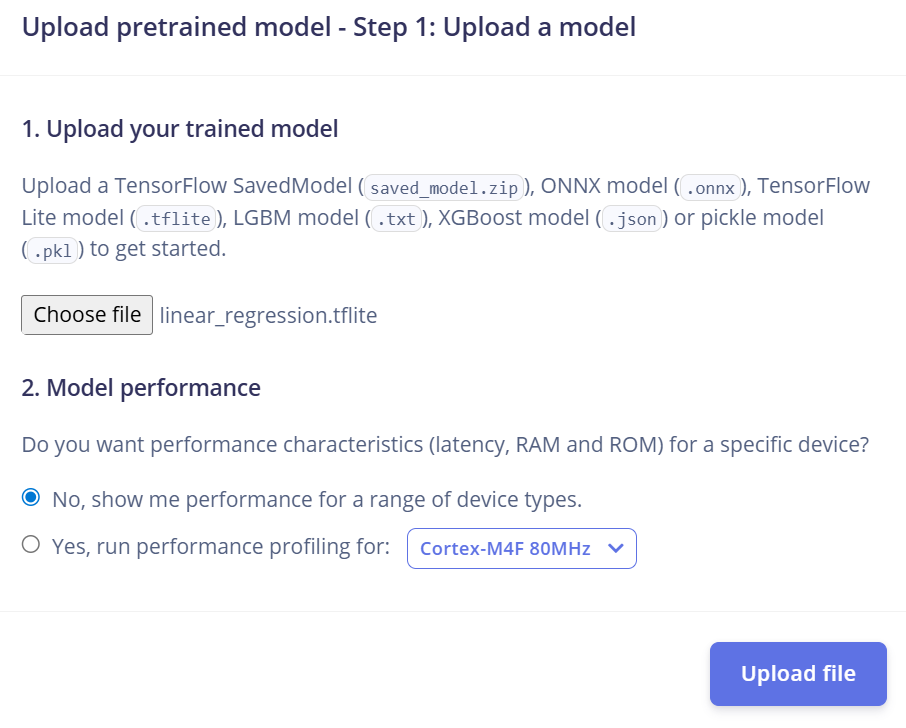

![Screenshot 2025-11-30 183912.png](<attachment:Screenshot 2025-11-30 183912.png>)
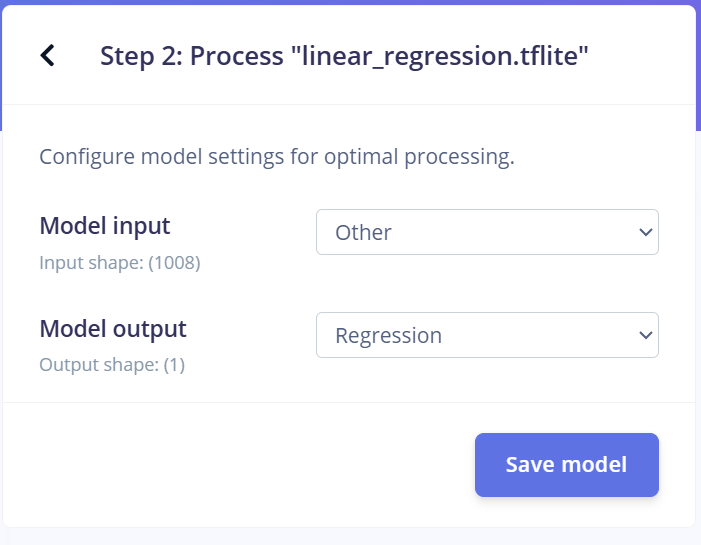

![Screenshot 2025-11-30 184100.png](<attachment:Screenshot 2025-11-30 184100.png>)
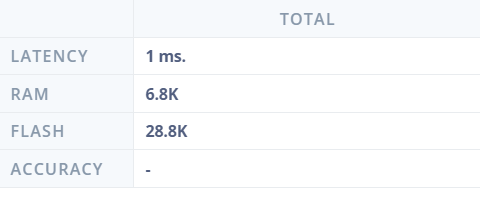

![Screenshot 2025-11-30 185635.png](<attachment:Screenshot 2025-11-30 185635.png>)
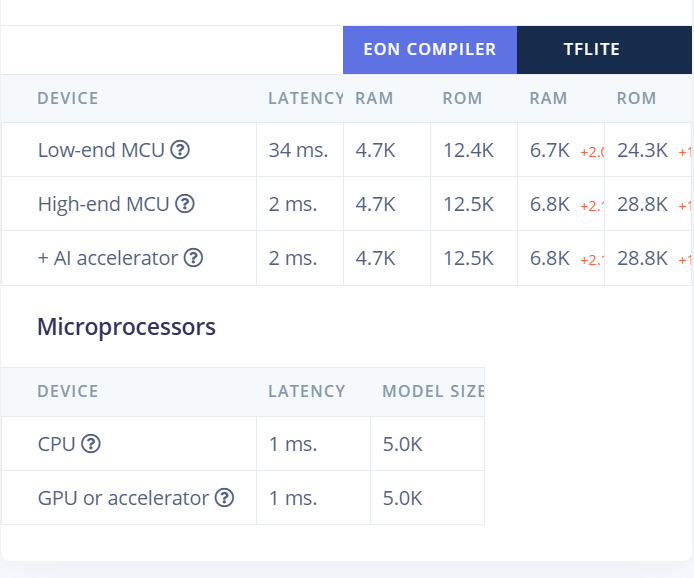

# BONUS TASKS

## Visualizations

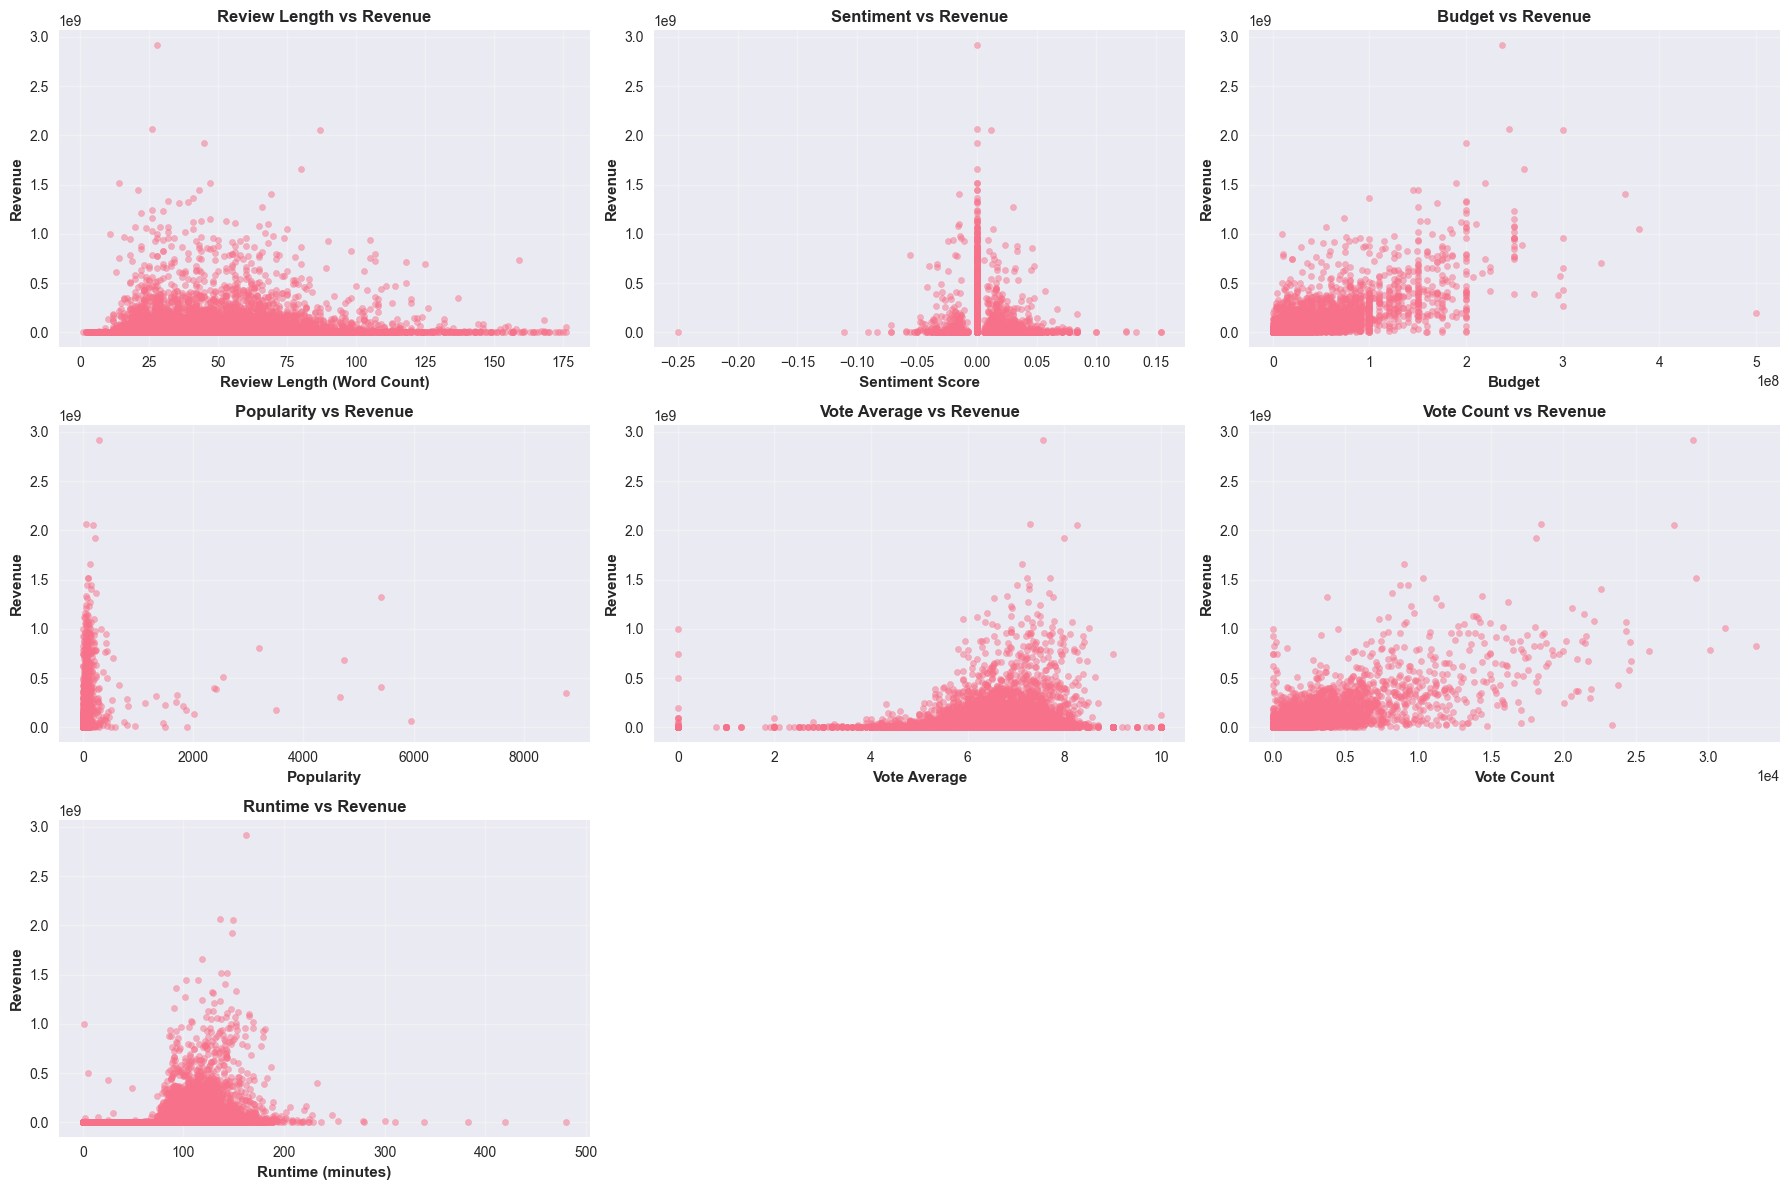

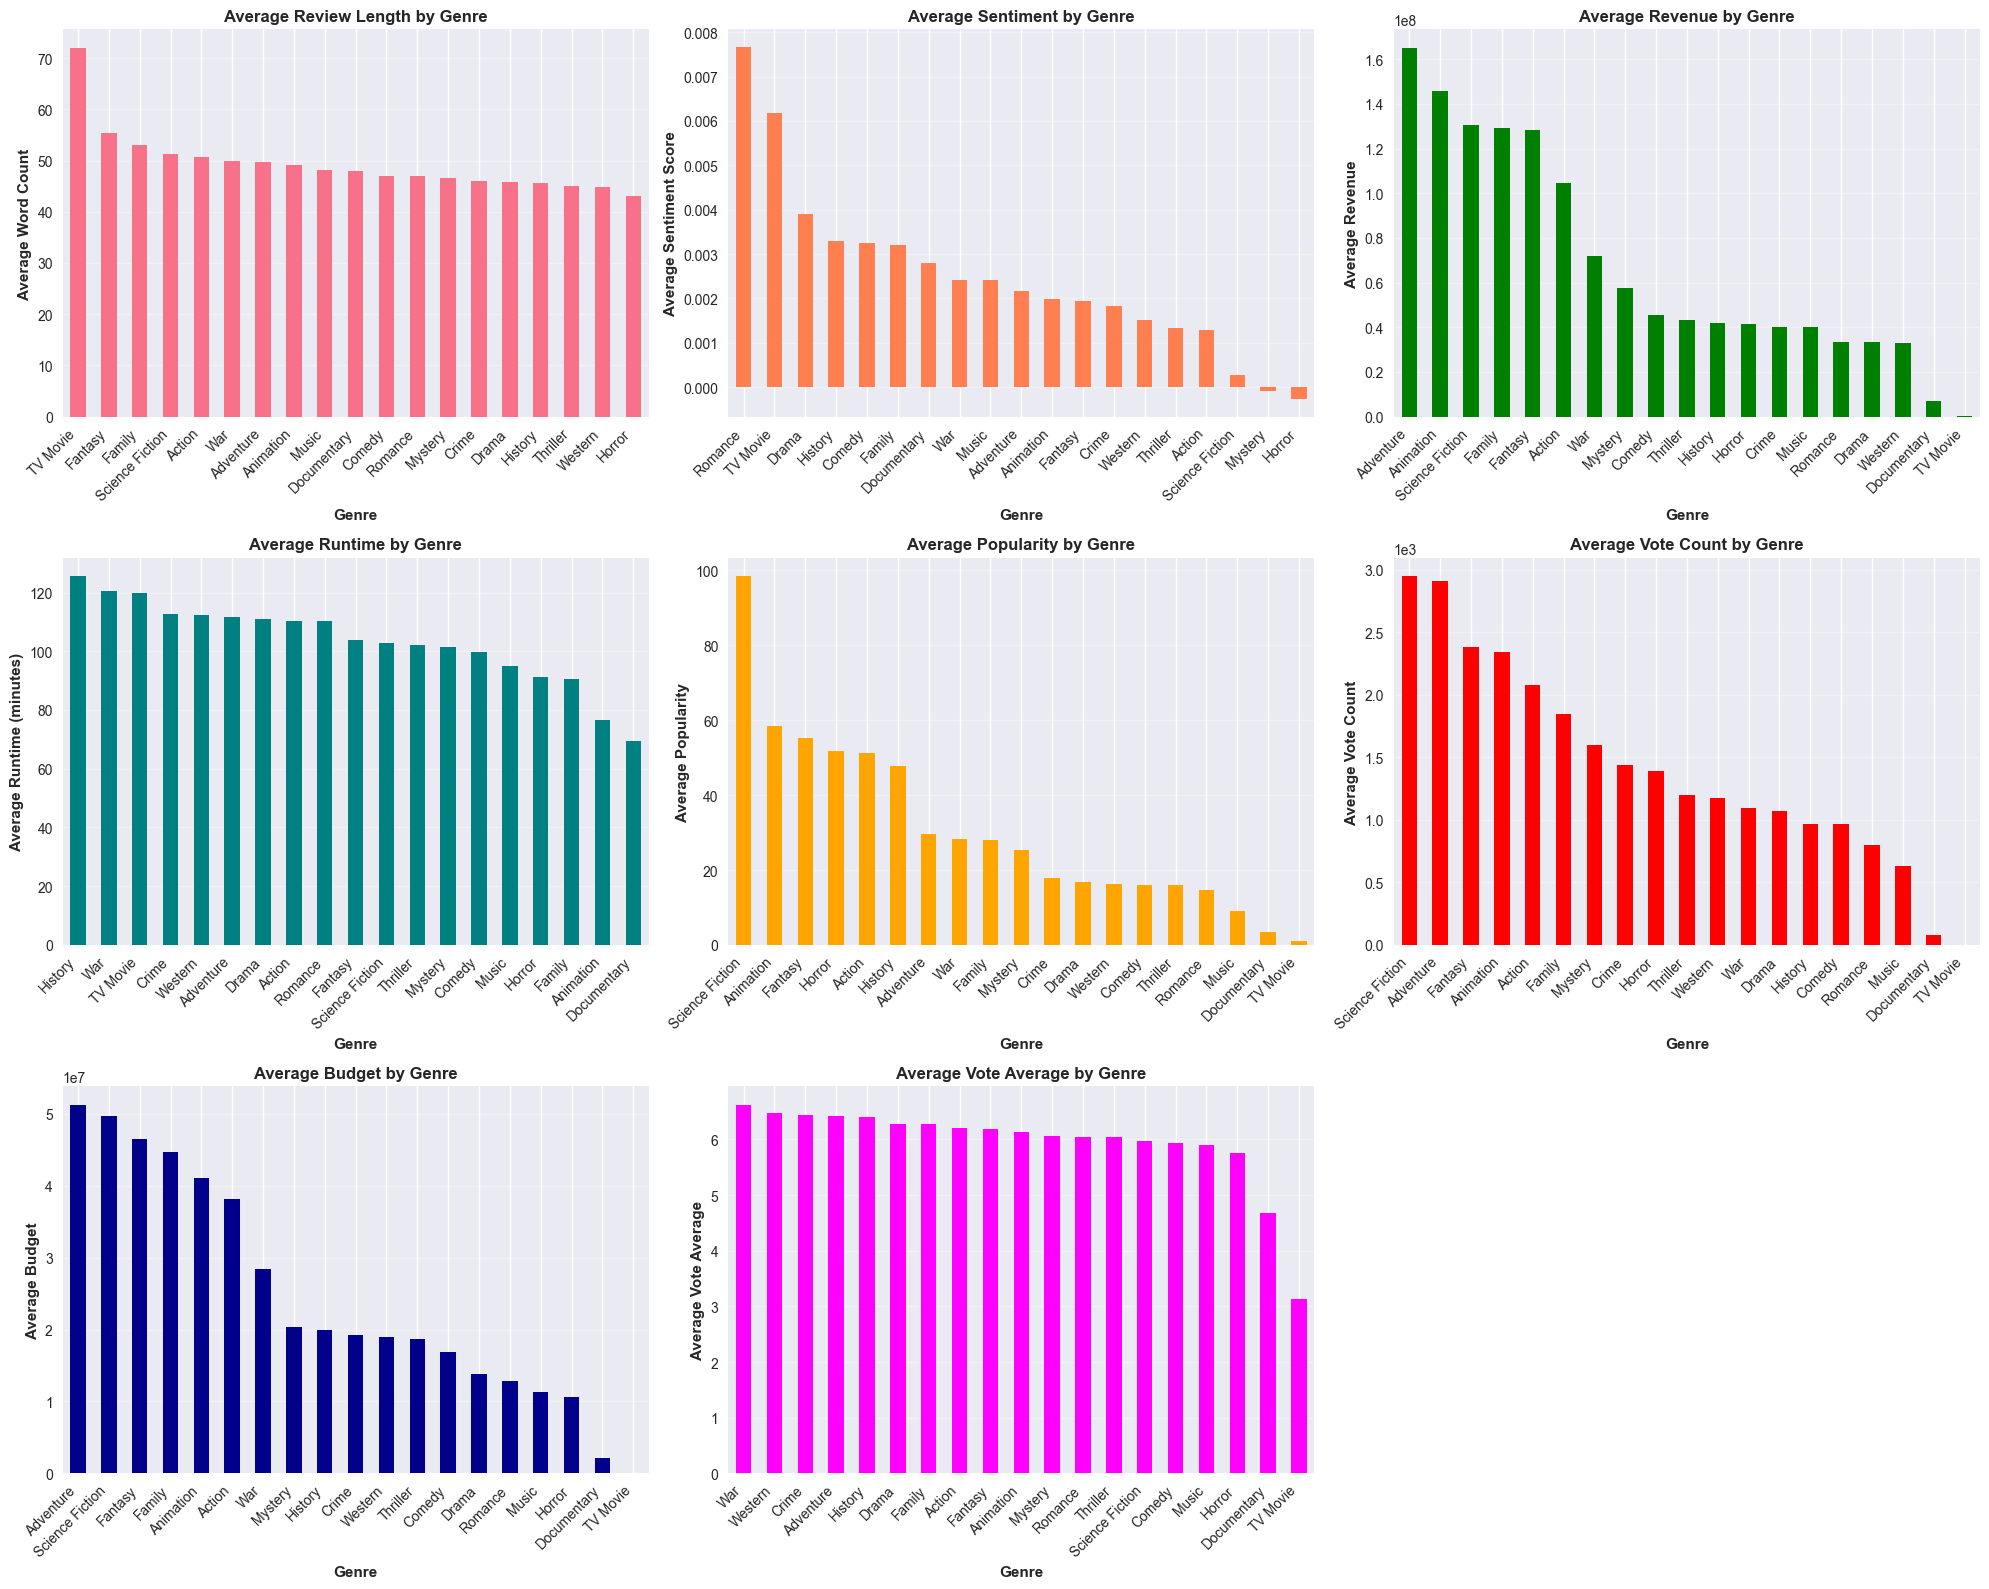

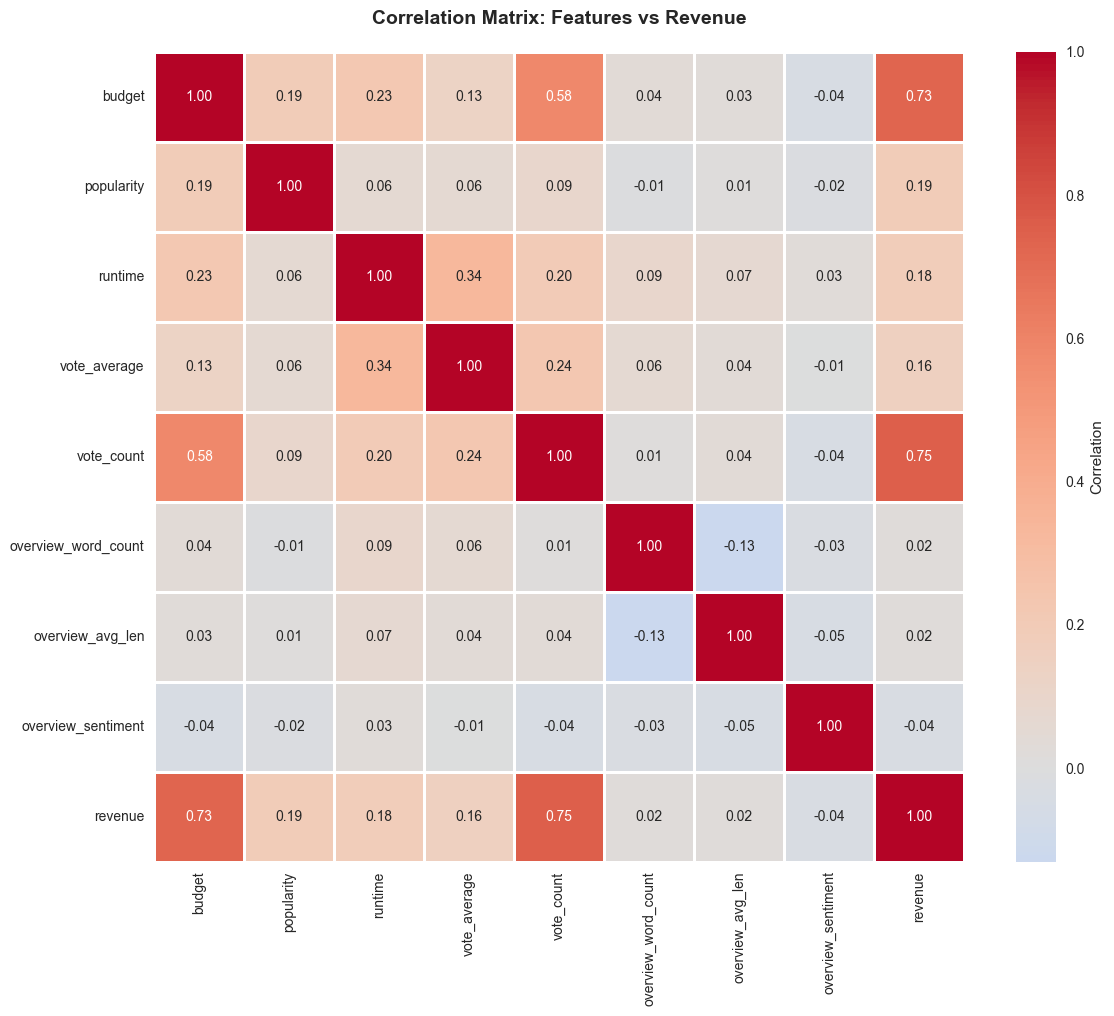

In [281]:
sns.set_palette("husl")
fig1 = plt.figure(figsize=(18, 12))
# 1. Review Length vs Revenue
ax1 = plt.subplot(3, 3, 1)
plt.scatter(train_df["overview_word_count"], train_df["revenue"], alpha=0.5, s=20)
plt.xlabel("Review Length (Word Count)", fontsize=11, fontweight='bold')
plt.ylabel("Revenue", fontsize=11, fontweight='bold')
plt.title("Review Length vs Revenue", fontsize=12, fontweight='bold')
plt.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
plt.grid(True, alpha=0.3)
# 2. Sentiment vs Revenue
ax2 = plt.subplot(3, 3, 2)
plt.scatter(train_df["overview_sentiment"], train_df["revenue"], alpha=0.5, s=20)
plt.xlabel("Sentiment Score", fontsize=11, fontweight='bold')
plt.ylabel("Revenue", fontsize=11, fontweight='bold')
plt.title("Sentiment vs Revenue", fontsize=12, fontweight='bold')
plt.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
plt.grid(True, alpha=0.3)
# 3. Budget vs Revenue
ax3 = plt.subplot(3, 3, 3)
plt.scatter(train_df["budget"], train_df["revenue"], alpha=0.5, s=20)
plt.xlabel("Budget", fontsize=11, fontweight='bold')
plt.ylabel("Revenue", fontsize=11, fontweight='bold')
plt.title("Budget vs Revenue", fontsize=12, fontweight='bold')
plt.ticklabel_format(style='scientific', axis='both', scilimits=(0,0))
plt.grid(True, alpha=0.3)
# 4. Popularity vs Revenue
ax4 = plt.subplot(3, 3, 4)
plt.scatter(train_df["popularity"], train_df["revenue"], alpha=0.5, s=20)
plt.xlabel("Popularity", fontsize=11, fontweight='bold')
plt.ylabel("Revenue", fontsize=11, fontweight='bold')
plt.title("Popularity vs Revenue", fontsize=12, fontweight='bold')
plt.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
plt.grid(True, alpha=0.3)
# 5. Vote Average vs Revenue
ax5 = plt.subplot(3, 3, 5)
plt.scatter(train_df["vote_average"], train_df["revenue"], alpha=0.5, s=20)
plt.xlabel("Vote Average", fontsize=11, fontweight='bold')
plt.ylabel("Revenue", fontsize=11, fontweight='bold')
plt.title("Vote Average vs Revenue", fontsize=12, fontweight='bold')
plt.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
plt.grid(True, alpha=0.3)
# 6. Vote Count vs Revenue
ax6 = plt.subplot(3, 3, 6)
plt.scatter(train_df["vote_count"], train_df["revenue"], alpha=0.5, s=20)
plt.xlabel("Vote Count", fontsize=11, fontweight='bold')
plt.ylabel("Revenue", fontsize=11, fontweight='bold')
plt.title("Vote Count vs Revenue", fontsize=12, fontweight='bold')
plt.ticklabel_format(style='scientific', axis='both', scilimits=(0,0))
plt.grid(True, alpha=0.3)
# 7. Runtime vs Revenue
ax7 = plt.subplot(3, 3, 7)
plt.scatter(train_df["runtime"], train_df["revenue"], alpha=0.5, s=20)
plt.xlabel("Runtime (minutes)", fontsize=11, fontweight='bold')
plt.ylabel("Revenue", fontsize=11, fontweight='bold')
plt.title("Runtime vs Revenue", fontsize=12, fontweight='bold')
plt.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
plt.grid(True, alpha=0.3)
ax8 = plt.subplot(3, 3, 8)
ax8.axis('off')
ax9 = plt.subplot(3, 3, 9)
ax9.axis('off')
plt.tight_layout()
plt.show()
fig2 = plt.figure(figsize=(20, 16))
# 1. Average Review Length by Genre
ax1 = plt.subplot(3, 3, 1)
genre_wordcount = train_df.groupby("main_genre")["overview_word_count"].mean().sort_values(ascending=False)
genre_wordcount.plot(kind='bar', ax=ax1)
plt.xlabel("Genre", fontsize=11, fontweight='bold')
plt.ylabel("Average Word Count", fontsize=11, fontweight='bold')
plt.title("Average Review Length by Genre", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
# 2. Average Sentiment by Genre
ax2 = plt.subplot(3, 3, 2)
genre_sentiment = train_df.groupby("main_genre")["overview_sentiment"].mean().sort_values(ascending=False)
genre_sentiment.plot(kind='bar', ax=ax2, color='coral')
plt.xlabel("Genre", fontsize=11, fontweight='bold')
plt.ylabel("Average Sentiment Score", fontsize=11, fontweight='bold')
plt.title("Average Sentiment by Genre", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
# 3. Average Revenue by Genre
ax3 = plt.subplot(3, 3, 3)
genre_revenue = train_df.groupby("main_genre")["revenue"].mean().sort_values(ascending=False)
genre_revenue.plot(kind='bar', ax=ax3, color='green')
plt.xlabel("Genre", fontsize=11, fontweight='bold')
plt.ylabel("Average Revenue", fontsize=11, fontweight='bold')
plt.title("Average Revenue by Genre", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
plt.grid(True, alpha=0.3, axis='y')
# 4. Average Runtime by Genre
ax4 = plt.subplot(3, 3, 4)
genre_runtime = train_df.groupby("main_genre")["runtime"].mean().sort_values(ascending=False)
genre_runtime.plot(kind='bar', ax=ax4, color='teal')
plt.xlabel("Genre", fontsize=11, fontweight='bold')
plt.ylabel("Average Runtime (minutes)", fontsize=11, fontweight='bold')
plt.title("Average Runtime by Genre", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
# 5. Average Popularity by Genre
ax5 = plt.subplot(3, 3, 5)
genre_popularity = train_df.groupby("main_genre")["popularity"].mean().sort_values(ascending=False)
genre_popularity.plot(kind='bar', ax=ax5, color='orange')
plt.xlabel("Genre", fontsize=11, fontweight='bold')
plt.ylabel("Average Popularity", fontsize=11, fontweight='bold')
plt.title("Average Popularity by Genre", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
# 6. Average Vote Count by Genre
ax6 = plt.subplot(3, 3, 6)
genre_votecount = train_df.groupby("main_genre")["vote_count"].mean().sort_values(ascending=False)
genre_votecount.plot(kind='bar', ax=ax6, color='red')
plt.xlabel("Genre", fontsize=11, fontweight='bold')
plt.ylabel("Average Vote Count", fontsize=11, fontweight='bold')
plt.title("Average Vote Count by Genre", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
plt.grid(True, alpha=0.3, axis='y')
# 7. Average Budget by Genre
ax7 = plt.subplot(3, 3, 7)
genre_budget = train_df.groupby("main_genre")["budget"].mean().sort_values(ascending=False)
genre_budget.plot(kind='bar', ax=ax7, color='darkblue')
plt.xlabel("Genre", fontsize=11, fontweight='bold')
plt.ylabel("Average Budget", fontsize=11, fontweight='bold')
plt.title("Average Budget by Genre", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
plt.grid(True, alpha=0.3, axis='y')
# 8. Average Vote Average by Genre
ax8 = plt.subplot(3, 3, 8)
genre_voteavg = train_df.groupby("main_genre")["vote_average"].mean().sort_values(ascending=False)
genre_voteavg.plot(kind='bar', ax=ax8, color='magenta')
plt.xlabel("Genre", fontsize=11, fontweight='bold')
plt.ylabel("Average Vote Average", fontsize=11, fontweight='bold')
plt.title("Average Vote Average by Genre", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
fig3 = plt.figure(figsize=(12, 10))
correlation_cols = ["budget", "popularity", "runtime", "vote_average", "vote_count", 
                    "overview_word_count", "overview_avg_len", "overview_sentiment", "revenue"]
corr_matrix = train_df[correlation_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={'label': 'Correlation'})
plt.title("Correlation Matrix: Features vs Revenue", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## Anomaly Detection Techniques

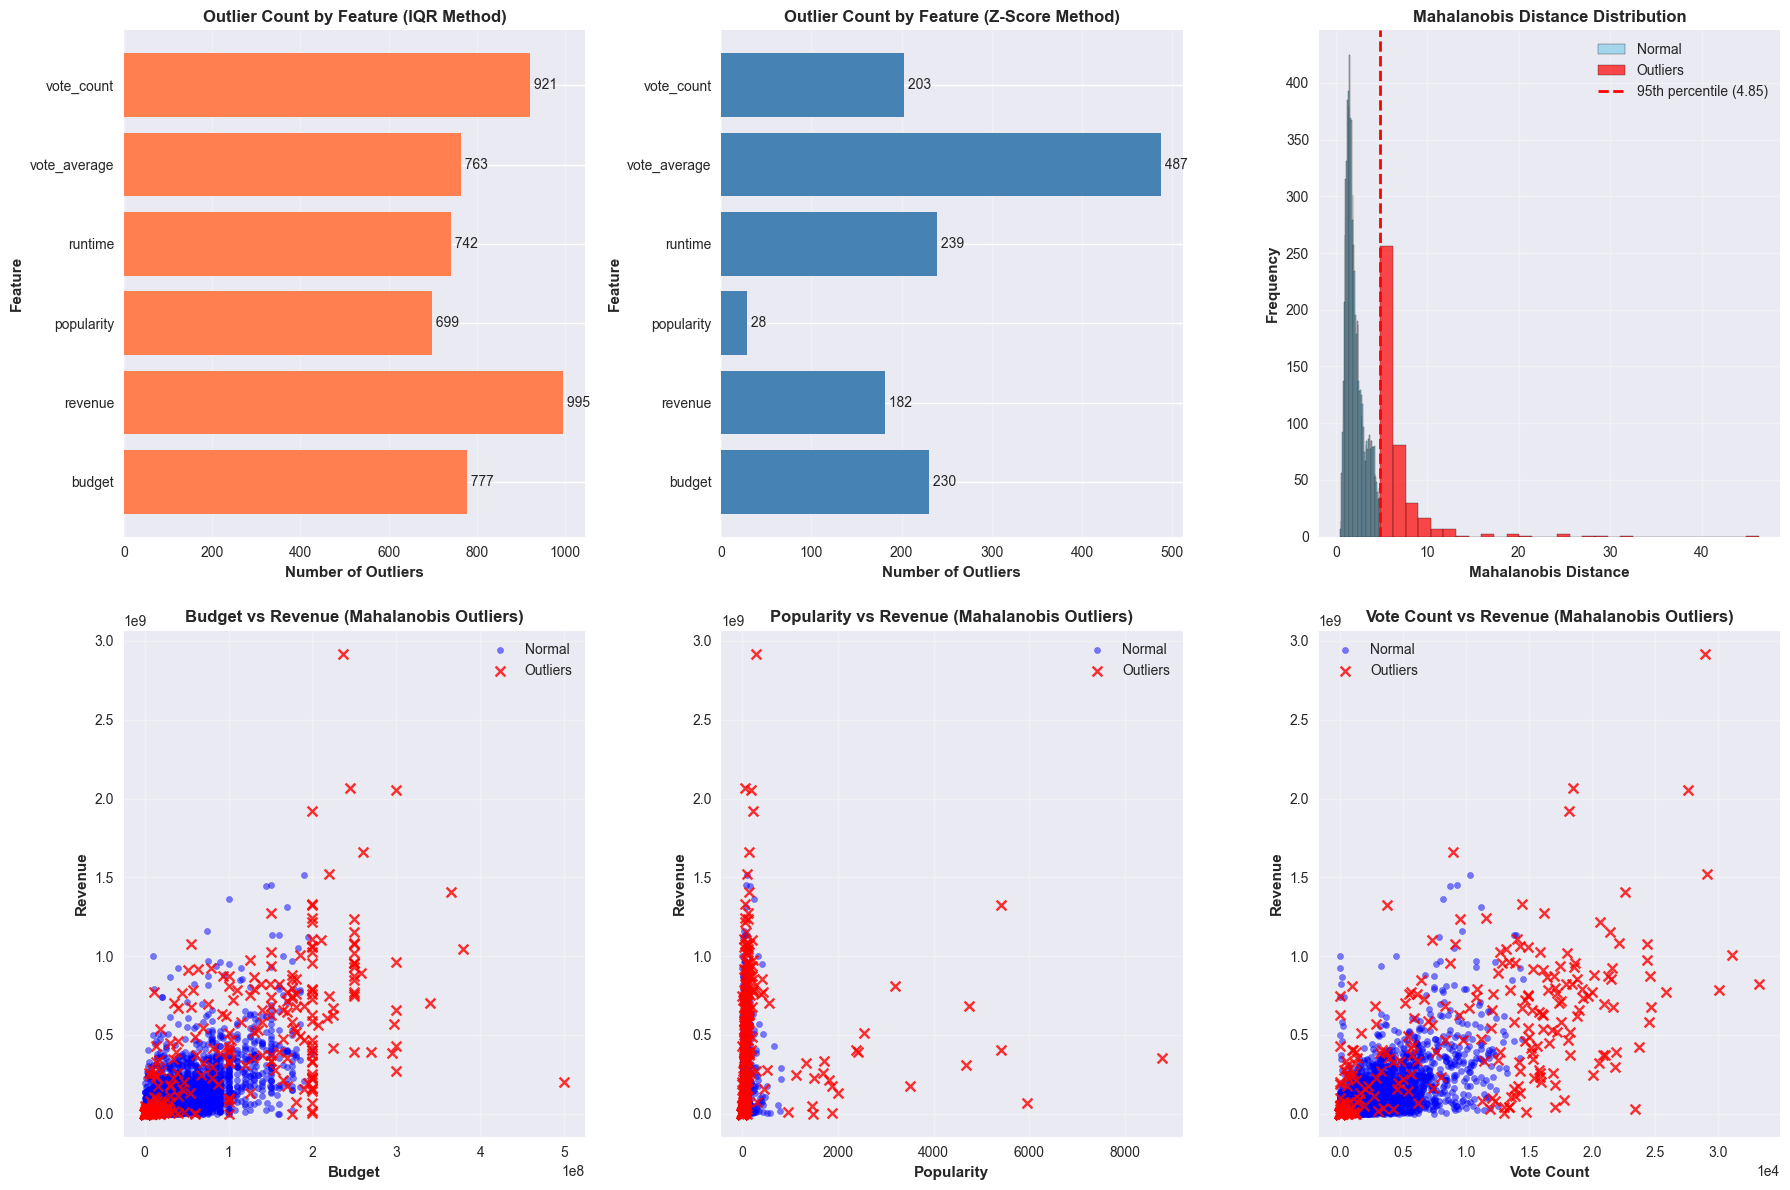

IQR Method - Total outliers: 2720 (33.32%)
Z-Score Method - Total outliers: 1369 across all features
Mahalanobis Method - Total outliers: 409 (5.01%)


In [282]:
def detect_outliers_iqr(data, feature_name, multiplier=1.5):
    """Detect outliers using Interquartile Range method"""
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    outliers = (data < lower_bound) | (data > upper_bound)
    return outliers, lower_bound, upper_bound
numeric_features = ["budget", "revenue", "popularity", "runtime", "vote_average", "vote_count"]
outlier_flags_iqr = {}
for feature in numeric_features:
    outliers, lower, upper = detect_outliers_iqr(train_df[feature], feature)
    outlier_flags_iqr[feature] = outliers
outlier_any_feature = np.zeros(len(train_df), dtype=bool)
for feature, flags in outlier_flags_iqr.items():
    outlier_any_feature |= flags
def detect_outliers_zscore(data, threshold=3):
    """Detect outliers using Z-score method"""
    z_scores = np.abs((data - np.mean(data)) / np.std(data))
    outliers = z_scores > threshold
    return outliers, z_scores
outlier_flags_zscore = {}
for feature in numeric_features:
    outliers, z_scores = detect_outliers_zscore(train_df[feature], threshold=3)
    outlier_flags_zscore[feature] = outliers
def compute_mahalanobis_distance(X):
    """Compute Mahalanobis distance for each sample"""
    mean = np.mean(X, axis=0)
    cov = np.cov(X.T)
    try:
        inv_cov = np.linalg.inv(cov)
    except np.linalg.LinAlgError:
        inv_cov = np.linalg.pinv(cov)
    diff = X - mean
    mahal_dist = np.sqrt(np.sum(diff @ inv_cov * diff, axis=1))
    return mahal_dist
# Compute Mahalanobis distance on normalized features
X_train_normalized = train_numeric
mahal_distances = compute_mahalanobis_distance(X_train_normalized)
threshold_95 = np.percentile(mahal_distances, 95)
outliers_mahal = mahal_distances > threshold_95
fig = plt.figure(figsize=(18, 12))
# 1. Outlier count by feature - IQR Method
ax1 = plt.subplot(2, 3, 1)
outlier_counts_iqr = [np.sum(outlier_flags_iqr[f]) for f in numeric_features]
plt.barh(numeric_features, outlier_counts_iqr, color='coral')
plt.xlabel("Number of Outliers", fontsize=11, fontweight='bold')
plt.ylabel("Feature", fontsize=11, fontweight='bold')
plt.title("Outlier Count by Feature (IQR Method)", fontsize=12, fontweight='bold')
for i, v in enumerate(outlier_counts_iqr):
    plt.text(v, i, f' {v}', va='center')
plt.grid(True, alpha=0.3, axis='x')
# 2. Outlier count by feature - Z-Score Method
ax2 = plt.subplot(2, 3, 2)
outlier_counts_zscore = [np.sum(outlier_flags_zscore[f]) for f in numeric_features]
plt.barh(numeric_features, outlier_counts_zscore, color='steelblue')
plt.xlabel("Number of Outliers", fontsize=11, fontweight='bold')
plt.ylabel("Feature", fontsize=11, fontweight='bold')
plt.title("Outlier Count by Feature (Z-Score Method)", fontsize=12, fontweight='bold')
for i, v in enumerate(outlier_counts_zscore):
    plt.text(v, i, f' {v}', va='center')
plt.grid(True, alpha=0.3, axis='x')
# 3. Mahalanobis Distance Distribution (showing outliers)
ax3 = plt.subplot(2, 3, 3)
plt.hist(mahal_distances[~outliers_mahal], bins=50, alpha=0.7, color='skyblue', edgecolor='black', label='Normal')
plt.hist(mahal_distances[outliers_mahal], bins=30, alpha=0.7, color='red', edgecolor='black', label='Outliers')
plt.axvline(threshold_95, color='red', linestyle='--', linewidth=2, label=f'95th percentile ({threshold_95:.2f})')
plt.xlabel("Mahalanobis Distance", fontsize=11, fontweight='bold')
plt.ylabel("Frequency", fontsize=11, fontweight='bold')
plt.title("Mahalanobis Distance Distribution", fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
# 4. Budget vs Revenue (with outliers highlighted)
ax4 = plt.subplot(2, 3, 4)
normal_points = train_df[~outliers_mahal]
outlier_points = train_df[outliers_mahal]
plt.scatter(normal_points["budget"], normal_points["revenue"], alpha=0.5, s=20, color='blue', label='Normal')
plt.scatter(outlier_points["budget"], outlier_points["revenue"], alpha=0.8, s=50, color='red', marker='x', label='Outliers')
plt.xlabel("Budget", fontsize=11, fontweight='bold')
plt.ylabel("Revenue", fontsize=11, fontweight='bold')
plt.title("Budget vs Revenue (Mahalanobis Outliers)", fontsize=12, fontweight='bold')
plt.legend()
plt.ticklabel_format(style='scientific', axis='both', scilimits=(0,0))
plt.grid(True, alpha=0.3)
# 5. Popularity vs Revenue (with outliers highlighted)
ax5 = plt.subplot(2, 3, 5)
plt.scatter(normal_points["popularity"], normal_points["revenue"], alpha=0.5, s=20, color='blue', label='Normal')
plt.scatter(outlier_points["popularity"], outlier_points["revenue"], alpha=0.8, s=50, color='red', marker='x', label='Outliers')
plt.xlabel("Popularity", fontsize=11, fontweight='bold')
plt.ylabel("Revenue", fontsize=11, fontweight='bold')
plt.title("Popularity vs Revenue (Mahalanobis Outliers)", fontsize=12, fontweight='bold')
plt.legend()
plt.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
plt.grid(True, alpha=0.3)
# 6. Vote Count vs Revenue (with outliers highlighted)
ax6 = plt.subplot(2, 3, 6)
plt.scatter(normal_points["vote_count"], normal_points["revenue"], alpha=0.5, s=20, color='blue', label='Normal')
plt.scatter(outlier_points["vote_count"], outlier_points["revenue"], alpha=0.8, s=50, color='red', marker='x', label='Outliers')
plt.xlabel("Vote Count", fontsize=11, fontweight='bold')
plt.ylabel("Revenue", fontsize=11, fontweight='bold')
plt.title("Vote Count vs Revenue (Mahalanobis Outliers)", fontsize=12, fontweight='bold')
plt.legend()
plt.ticklabel_format(style='scientific', axis='both', scilimits=(0,0))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"IQR Method - Total outliers: {np.sum(outlier_any_feature)} ({np.sum(outlier_any_feature)/len(train_df)*100:.2f}%)")
print(f"Z-Score Method - Total outliers: {np.sum([np.sum(outlier_flags_zscore[f]) for f in numeric_features])} across all features")
print(f"Mahalanobis Method - Total outliers: {np.sum(outliers_mahal)} ({np.sum(outliers_mahal)/len(train_df)*100:.2f}%)")